In [11]:
import numpy as np
from numpy.linalg import matrix_power
from scipy.stats import entropy
import matplotlib.pyplot as plt
import matplotlib as mpl

import os, sys, pathlib
os.environ["OPENBLAS_NUM_THREADS"] = "1"
_project_root = pathlib.Path.cwd().resolve()
sys.path.insert(0, str(_project_root.parents[0]))
sys.path.insert(0, str(_project_root.parents[1]))

from src.categorization import show_latex_bmatrix
import src.symmetry.permutations as perms
from src.symmetry.permutations import perm_from_cycles, perm_hom, generated_group

In [ ]:
def pop(p0, G, N):
  p_avg = np.zeros_like(p0, dtype=float)
  if N==0:
    return np.zeros_like(p0)
  for t in range(0, N):
      p_avg += matrix_power(G, t) @ p0

  return p_avg / N


def pmmc(p0, G, N):
  p_avg = pop(p0, G, N)
  return (
      entropy(matrix_power(G, N) @ p0)
      - entropy(p0)
      + N * (entropy(p_avg) - entropy(G @ p_avg))
  )

def JS(distributions, base=np.e):
  P = np.asarray(distributions, dtype=float)
  P /= P.sum(axis=1, keepdims=True)

  M = P.mean(axis=0)

  return len(P) * entropy(M, base=base) - np.sum([entropy(p, base=base) for p in P])

In [ ]:
# Probability of reading a 0
p = 0.7
q = round(1 - p)

Ns=np.arange(1,500)

G3 = np.array([
    [p, q, 0],
    [q, 0, p],
    [0, p, q]
], dtype=float)

p0 = [1,0,0]
G3_mmc = np.array([
    pmmc(p0, G3, N)
    for N in Ns
])

G3_pts = np.array([matrix_power(G3,t)@p0 for t in range(max(Ns)-1)])

G6 = np.zeros((6, 6))

G6 = np.array([
    [0, p, 0, q, 0, 0],
    [p, 0, q, 0, 0, 0],
    [0, q, 0, 0, 0, p],
    [q, 0, 0, 0, p, 0],
    [0, 0, 0, p, 0, q],
    [0, 0, p, 0, q, 0]
], dtype=float)

p0 = [1,0,0,0,0,0]
G6_mmc = np.array([
    pmmc(p0, G6, N)
    for N in Ns
])

G6_pts = np.array([matrix_power(G6,t)@p0 for t in range(max(Ns)-1)])

Gmem = np.array([
    [p, p, 0, 0, 0, 0],
    [0, 0, q, q, 0, 0],
    [0, 0, 0, 0, p, p],
    [q, q, 0, 0, 0, 0],
    [0, 0, p, p, 0, 0],
    [0, 0, 0, 0, q, q]
], dtype=float)

Gmem_mmc = np.array([
    pmmc(p0, Gmem, N)
    for N in Ns
])

Gmem_pts = np.array([matrix_power(Gmem,t)@p0 for t in range(max(Ns)-1)])

G12 = np.array([
#   0  1  2  3  4  5  6  7  8  9  10 11
   [p, 0, 0, 0, p, 0, 0, 0, 0, 0, 0, 0],  # 0  (0,0,0)
   [q, 0, 0, 0, q, 0, 0, 0, 0, 0, 0, 0],  # 1  (0,0,1)
   [0, q, 0, 0, 0, q, 0, 0, 0, 0, 0, 0],  # 2  (0,1,0)
   [0, p, 0, 0, 0, p, 0, 0, 0, 0, 0, 0],  # 3  (0,1,2)
   [0, 0, p, 0, 0, 0, 0, 0, p, 0, 0, 0],  # 4  (1,0,0)
   [0, 0, q, 0, 0, 0, 0, 0, q, 0, 0, 0],  # 5  (1,0,1)
   [0, 0, 0, p, 0, 0, 0, 0, 0, p, 0, 0],  # 6  (1,2,1)
   [0, 0, 0, q, 0, 0, 0, 0, 0, q, 0, 0],  # 7  (1,2,2)
   [0, 0, 0, 0, 0, 0, q, 0, 0, 0, q, 0],  # 8  (2,1,0)
   [0, 0, 0, 0, 0, 0, p, 0, 0, 0, p, 0],  # 9  (2,1,2)
   [0, 0, 0, 0, 0, 0, 0, p, 0, 0, 0, p],  # 10 (2,2,1)
   [0, 0, 0, 0, 0, 0, 0, q, 0, 0, 0, q],  # 11 (2,2,2)
], dtype=float)

p0 = [1,0,0,0,0,0,0,0,0,0,0,0]

G12_mmc = np.array([
    pmmc(p0, G12, N)
    for N in Ns
])


NameError: name 'Ns' is not defined

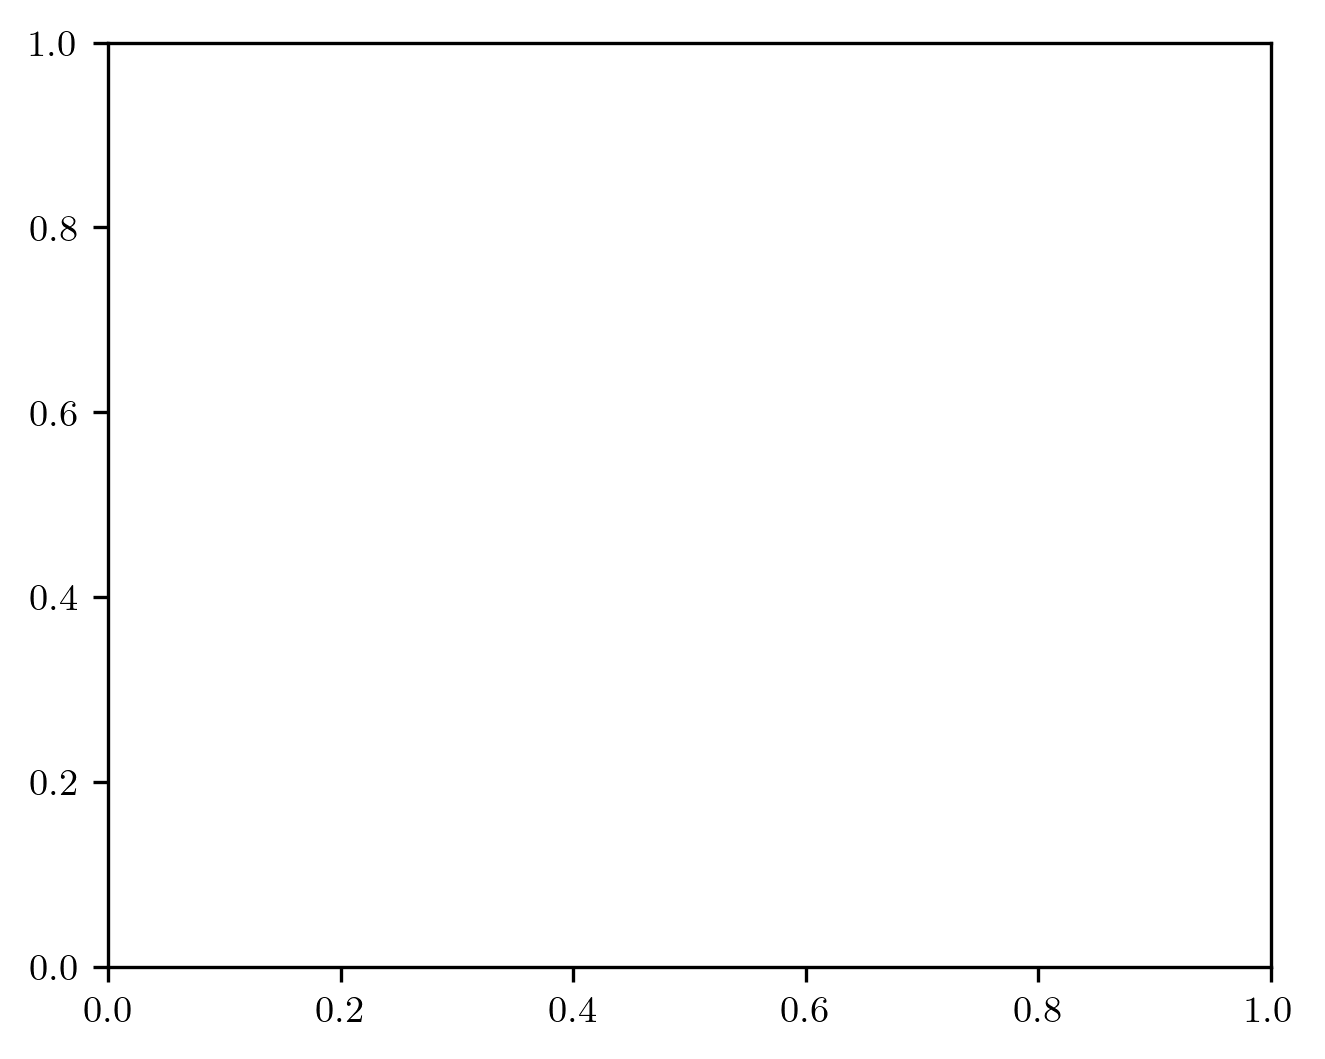

In [2]:
mpl.rcParams.update({
  "font.size": 16,
  "axes.titlesize": 20,
  "axes.labelsize": 16,
  "xtick.labelsize": 9,
  "ytick.labelsize": 9,
  "figure.dpi": 300,
  "savefig.dpi": 300,
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "mathtext.fontset": "dejavusans",
  "text.usetex": True,
  "font.family": "Computer Modern Roman",
})

fig, ax = plt.subplots(figsize=(5,4))

# plt.plot(Ns, G4_mmc, color='red', label='minimal')
# plt.plot(Ns, G20_mmc, color='blue', label='original')
ax.semilogx(Ns, G3_mmc, color='black', label='A (minimal)')
ax.semilogx(Ns, G6_mmc, color = 'black' ,linestyle = 'dashed', label='B (invertible)')
ax.semilogx(Ns, Gmem_mmc, color='black', linestyle='-.', label='C (noninvertible)')
ax.semilogx(Ns, G12_mmc, color='black', linestyle='dotted')
ax.legend(fontsize='x-small' ,loc='upper left')
ax.set_title(fr'p(0)={p}, p(1)={q}')
ax.set_ylabel('Minimal periodic MMC')
ax.set_xlabel('Number of iterations')

plt.savefig('/Users/benjmainansbacher/Documents/POP projectg/DFAplot.pdf')

We can write, for this matrix for example,
$$
G_3 = p P_0 + q P_1,
$$
where $q=1-p$. Here $P_0$ and $P_1$ are binary matrices describing the paths taken upon receiving a $0$ and a $1$ on the next bit in the string, respectively. Now, consider any states that have ''arrows to them selves,'' i.e., $1$'s on the diagonal. We can create a DFA that is equivalent to this one by ''enlarging'' the space of the state which is mapped to itself, i.e., when this state is mapped to itself, we instead map it to another state which has an equivalent path out. Another way to say this is that we turn this subspace into a cycle between equivalent states. 

Write the space upon which $G_3$ acts upon as a direct sum:
$$
\mathbb{R}^3 = \mathbb{R} \oplus \mathbb{R} \oplus \mathbb{R},
$$
corresponding to the state space. Now, to add a cycling state, we can enlarge the space on one of the states that maps to itself:
$$
\mathbb{R}^4 = \mathbb{R}^2 \oplus \mathbb{R} \oplus \mathbb{R},
$$


Alternatively, break each of $P_0$ and $P_1$ into irreps:
$$
P_0: \mathbb{R} \oplus \mathbb{R}^2, \quad P_1: \mathbb{R}^2 \oplus \mathbb{R}.
$$
Each one-dimensional irrep corresponds to a fixed point of $P_i$, i.e., a state which maps to itself. Enlarge the space upon which the group acts:
$$
P_0: \mathbb{R} \oplus \mathbb{R} \oplus \mathbb{R}^2, \quad P_1: \mathbb{R} \oplus \mathbb{R}^2 \oplus \mathbb{R}.
$$
Note we may write 
$$
P_0 = \mathbb{I}_1 \oplus \mathbb{I}_1 \oplus R_0, \quad P_1 = \mathbb{I}_1 \oplus R_1 \oplus \mathbb{I}_1.
$$
As is, this is problematic, as starting in $\delta_0$ fixes the state in the first irrep permanently. Instead, we consider a group action on the first two subspaces. We must do this such that it acts irreducibly on these subspaces. For example, the cyclic group $C_2$



Recall, the mismatch cost is
$$
\mathcal{M}(p_0) = D(p_0\|q) - D(Gp_0\| Gq)
$$
while the periodic mismatch cost is
$$
\mathcal{M}_N(p_0) = \sum_{t=0}^{N-1}\mathcal{M}(G^t p_0)
$$
Also, recall the KL divergence is defined as
$$
D(p\|q) = \sum_i p_i \log (p_i/q_i).
$$
Now, by definition, the KL divergence is additive for independent components, i.e., if 
$p=\alpha_1 p_1 \oplus \alpha_2 p_2$ and 
$q=\beta_1 q_1 \oplus \beta_2 q_2$. 
However, if they mix, it is a different story. Generally, let 
$P=\sum_i w_i P_i$
and
$Q=\sum_i u_i Q_i$,
so
$$
D(P\|Q) = \sum_i w_i P_i (\log w_i P_i  -\log u_i Q_i)= \sum_i w_i P_i (\log P_i + \log w_i - \log Q_i - \log u_i),
$$
so
$$
D(P\|Q) = \sum_i w_i P_i (\log(P_i/Q_i) + \log(w_i/u_i))
$$
<!-- $$
D(P\|Q) = \sum_j (\sum_i w_i P_i)_j [\log (\sum_i w_i P_i)_j - \log(\sum_i u_i Q_i)_j] = \sum_i \sum_j (w_i P_i)_j[\log (\sum_i w_i P_i)_j - \log(\sum_i u_i Q_i)_j], 
$$\
but $w_i$ is a constant, so we have
$$
D(P\|Q) =\sum_i w_i \sum_j (P_i)_j[\log (\sum_i w_i P_i)_j - \log(\sum_i u_i Q_i)_j], 
$$

Let $G=p P_0 + q P_1$, so 
$$
D(Gp_0\| Gq) = \sum_x (pP_0 + qP_1) p_0 \log (Gp_0/Gq) = p \sum_x P_0p_0 \log(Gp_0/Gq) + q \sum_x P_1p_0 \log(Gp_0/Gq)
$$
so 
$$
D(Gp_0\| Gq) 
= p \sum_x P_0p_0 [\log Gp_0 - \log Gq] + q \sum_x P_1p_0 [\log Gp_0 - \log Gq] 
= - \sum_x Gp_0\log Gq + p\sum_x P_0 p_0 \log Gp_0 + q\sum_x P_1 p_0 \log Gp_0
$$
However, $\log$ is concave, so $\log(pP_0p_0 + qP_1p_0)_x\geq p\log (P_0 p_0)_x + q\log(P_1p_0)_x$, so we have:
$$
D(Gp_0\| Gq)\geq - \sum_x Gp_0\log Gq + p\sum_x (P_0 p_0)_x[p\log (P_0 p_0)_x + q\log(P_1p_0)_x] + q \sum_x (P_1 p_0)_x[p\log (P_0 p_0)_x + q\log(P_1p_0)_x]
$$
$$
=- \sum_x Gp_0\log Gq - p^2 S(P_0p_0) - q^2 S(P_1p_0) + pq \sum_x (P_0 p_0)_x \log(P_1p_0)_x + qp \sum_x (P_1 p_0)_x\log (P_0 p_0)_x
$$ -->

We may write $G$ as an element of the group algebra $\mathbb{R}[S_3]$:
$$
G = p \rho((2\,3)) + (1 - p) \rho((1\,2))
$$
Now, when we expand state 0, we instead have it as an element of $\mathbb{R}[S_4]$:
$$
G = p \rho((1\,2)(3\,4)) + (1 - p) \rho((2\,3)).
$$

Now, the evolution of an initial distribution $p_0$ is governed by the operator $G$, and the distribution at step $n$ is given by $p_n=G^np_0$, which is the convolution $p_n=\mu^{*n}p_0$:
$$
(Gp_0)(x) = ([\sum_{g\in H}\mu(g)\rho(g)]p_0)(x) = \sum_{g\in H}\mu(g)[\rho(g)p_0](x) = \sum_{g\in H}\mu(g) p_0(g^{-1}\cdot x).
$$
Thus, we have shown that 
$$
\pi = \lim_{N\to\infty}\sum_{n=0}^{N-1} p_n = \lim_{N\to\infty}\sum_{n=0}^{N-1} \mu^{*n}p_0.
$$
Let us look at the Group Fourier transform of the function $\mu: H\to [0, 1]$:
$$
\mathcal{F}(\mu)(\rho) = \sum_{g\in H} \mu(g)\rho(g).
$$
Note that
$$
\mathcal{F}(\mu)(\sigma\oplus\rho) = \mathcal{F}(\mu)(\sigma)\oplus\mathcal{F}(\mu)(\rho),
$$
but if $\sigma$ is the trivial rep, we have
$$
\mathcal{F}(\mu)(\sigma\oplus\rho) = \sum_{g\in H} \mu(g) (1) \oplus\mathcal{F}(\mu)(\rho),
$$
and since $\mu: H\to [0,1]$ is itself a probability distribution, we have
$$
\mathcal{F}(\mu)(\sigma\oplus\rho) = (1) \oplus\mathcal{F}(\mu)(\rho),
$$
Therefore, since
$$
\mathcal{F}(\mu^{*n}) = \mathcal{F}(\mu)^n, \quad \mathcal{F}(\mu*p_0) = \mathcal{F}(\mu)\mathcal{F}(p_0)
$$
where the multiplication on RHS is taken coordinatewise,
$$
\mathcal{F}(\mu^{*n})(\sigma\oplus\rho) = (1^n)\oplus (\mathcal{F}(\mu)^n(\rho))\mathcal{F}(p_0)
$$

The **Fourier Transform** of $f$ is
$$
\mathcal{F}: \mathcal{L}^2(G) \to \mathrm{End}(V_1)\oplus\cdots\oplus\mathrm{End}(V_r)
$$
$$
f\mapsto \mathcal{F}(f) = (\hat{f}(\rho_1),\dots,\hat{f}(\rho_r))
$$
The Fourier transform is a vector space isomorphism. The *inverse* Fourier transform is given by
$$
\mathcal{F}^{-1}: \mathrm{End}(V_1)\oplus\cdots\oplus \mathrm{End}(V_r)\to\mathcal{L}(H)
$$
$$
T_1+\cdots +T_r\mapsto \left(g\mapsto \frac{1}{|H|} \sum_{i=1}^r \mathrm{dim} V_i \mathrm{Tr}(\rho_i(g^{-1})T_i)\right).
$$


Thus, 
$$
\mathcal{F}^{-1}((1)\oplus(\mathcal{F}(\mu)^n(\rho))\mathcal{F}(p_0))=\frac{1}{|H|} + \mathcal{F}^{-1}((\mathcal{F}(\mu)^n(\rho))\mathcal{F}(p_0))
$$

For $\mu\in\mathcal{L}^2(G)$ with $\mu: G\to [0, 1]$, 
$$
\hat{\mu}(\rho) := \sum_{g\in G}\mu(g)\rho(g)\in\mathrm{End}(V)
$$
Also, we can see $p_0: \mathcal{X}\to [0,1]$, 

Representation theory is a very fitting way to describe all this, given that. DFA is a discreate graph of permuting states, and rep theory is the study of group actions.

**NOTE:** We need some clarification. For a DFA with states $\mathcal{X}$, $p_0$ is a distribution over those states 
$p_0:\mathcal{X}\to [0,1]$. 
The group $H$ acts on the states $\mathcal{X}$ via permutation.
The operator $G$ is an element of the group algebra of $H$ and may be written as 
$$
G = \sum_{g\in H}\mu(g)\rho(g),
$$
where $\mu(g): H\to [0,1]$. This is actually (I think???) the Fourier transform of $\mu$:
$$
\hat{\mu}(\rho) := \sum_{g\in H} \mu(g)\rho(g).
$$
Indeed, in this space, $\widehat{\mu * \mu} = \hat{\mu}^2$. I'm not really sure what the meaning of $Gp_0$ is, though. I guess the orbit of an element $p_0$ of the space $\mathcal{X}$ on which $H$ acts? No, not the orbit. This is the action, or, rather, sum of actions, that $G$ induces on $p_0$? 

I guess this actually makes our optimal prior the orbit! or the symmetrized orbit...


We assume that the non-minimal DFAs we create act irreducibly. Let 
$$
H=\langle g_0, g_1\rangle,
$$
where $\rho(g_0)=P_0$ and $\rho(g_1)=P_1$. 
Indeed, we have
$$
G^n p_0 = (\widehat{\mu^{*n}})p_0 = (\hat{\mu}^n)p_0 = (\mu(g_0)\rho(g_0) + \mu(g_1)\rho(g_1))^np_0.
$$
We have $\rho$ is irreducible. Otherwise... **TODO**. Take trace:
$$
\mathrm{Tr}(G) = d
$$


$$
T_0 = \begin{bmatrix} 
  R & 0 & 0 \\
  0 & 0 & \mathbf{1}^\top \\
  0 & e_0 & 0
\end{bmatrix},
\quad
T_1 = \begin{bmatrix} 
  0 & e_0 & 0 \\
  \mathbf{1}^\top & 0 & 0 \\
  0 & 0 & R
\end{bmatrix},
\quad
G_L = p T_0 + q T_1 = \begin{bmatrix} 
  pR & q e_0 & 0 \\
  p\mathbf{1}^\top & 0 & q\mathbf{1}^\top \\
  0 & pe_0 & qR
\end{bmatrix},
$$

Let
$$
C = \begin{bmatrix}
  \mathbf{1}^\top & 0 & 0 \\
  0 & 1 & 0 \\
  0 & 0 & \mathbf{1}^\top 
\end{bmatrix}
$$,
so we have the intertwining relation / equivariant function
$$
CG_L = G_3 C
$$
Let $K=\mathrm{ker} \,C$, so
$$
v\in K\implies CG_Lv = G_3 Cv = 0.
$$
Thus,
$$
G_L K\subseteq K
$$

I think this also gives a short-exact sequence:

$$
0\to K \xrightarrow{\varphi} V_L \xrightarrow{C} V_{\mathrm{min}} \to 0,
$$
where $\mathrm{im}\,\varphi = K = \mathrm{ker}\, C$ and $V_L\cong\mathbb{C}^{2L+1}$ and $V_{\mathrm{min}}\cong\mathbb{C}^3$. The quotient representation is precisely the minimal DFA, i.e., since $\mathrm{ker}\, C=K$, we have
$$
V_L / K \cong V_{\mathrm{min}}.
$$


Alternatively, let $\pi_L$ be the steady-state of $G_L$, i.e., eigenvector with eigenvalue 1. Thus, from the intertwining relation,
$$
CG_L\pi_L = C\pi_L = G_3 C\pi_L,
$$
meaning $C\pi_L$ is the steady-state of $G_3$. By definition of $C$, though, we have that $\sum_i \pi_L(A_i) = \pi(A)$, where $\pi_L(A_i)$ and $\pi(A)$ are the values of the steady-state distribution of $G_L$ at state $A_i$ and $G_3$ at state $A$, respectively. Thus, we necessarily have $\pi_L(A_i)\leq \pi(A)$. To show the strict inequality, assume $\pi_L(A_i)=\pi(A)$, so $\pi_L(A_j)=0$ for all $j\neq i$. However, we have that, for all $j$, $G_L\pi(A_j)=pT_0\pi(A_j) + q T_1\pi(A_j) = p\pi(A_{j+1}) + q\pi(B)$. Actually, the steady-state probability at state $A_j$ follows
$$
\pi(A_j) = (G_L\pi)(A_j) = ((p T_0 + q T_1)\pi)(A_j) = p \pi(A_{j-1}) + q\delta_{j0} \pi(A_j).
$$
Thus, the mass of $\pi(A_i)$ couples to the mass of all $\pi(A_j)$, unless $p=0$.


Let $\widetilde{\mathcal{A}}$ be a redundant DFA with states $\widetilde{\mathcal{X}}$ and $\mathcal{A}$ a coarser, equivalent (accepts the same language) DFA with states $\mathcal{X}$. Suppose there is a surjective deterministic map between the state spaces
$$
C:\widetilde{\mathcal{X}}\to \mathcal{X},
$$
such that, symbol-by-symbol (i.e., reading a 0 bit vs reading a 1 bit) we have the intertwining relation
$$
C\widetilde{T}_a = T_a C
$$
Then, by definition we have $G$ as a convex sum over the per-symbol operators $T_a$, i.e., $G = \sum_a p_a T_a$. Consequently, for the stochastic operators we also have the equivariance relation
$$
C\widetilde{G} = GC.
$$
Now, if the induced action of $C$ over distributions of states follows $\tilde{p}_0\mapsto p_0 = C\tilde{p}_0$, then, at every time $t$, we have 
$$
C\widetilde{G}^t \tilde{p}_0 = G^tC\tilde{p}_0 = G^t p_0 \implies C \tilde{p}^t = p^t.
$$
Now, assuming $G$ and $\tilde G$ are irreducible, and so have unique eigenvectors with eigenvalue 1, or fixed points $\pi$ and $\tilde{\pi}$, then the intertwining gives
$$
GC\tilde{\pi} = C\widetilde{G}\tilde{\pi} = C\tilde{\pi},
$$
so since $\pi$ is unique, we have 
$C\tilde{\pi} = \pi$.
Now, using the data-processing inequality with respect to $C$, we have
$$
D(\tilde{p}_0\| \tilde{\pi}) \geq D(C\tilde{p}_0\| C\tilde{\pi}) = D(p_0\|\pi).
$$
<!-- Note that by the KL-divergence chain rule $D(p(x,y)\|q(x,y)) = D(p(x)\|q(x)) + D(p(y|x)\|q(y|x))$
$$
D(\tilde{p}_0\| \tilde{\pi}) -  D(p_0\|\pi) = \sum_y (C\tilde{\pi})_y D(C'\| C'_\pi)
$$
where
$$
C'(x|y) = \frac{C(y|x)\tilde{p}_0(x)}{(C(y|x)\tilde{p}_0)_y}
$$
and 
$$
C'_\pi(x|y) = \frac{C(y|x)\tilde{\pi}(x)}{(C(y|x)\tilde{\pi})_y},
$$
This is just zero iff $C'(x|y) = C'_\pi(x|y)$, so iff
$$
\frac{\tilde{p}_0(x)}{(C(y|x)\tilde{p}_0)_y} = \frac{\tilde{\pi}(x)}{(C(y|x)\tilde{\pi})_y},
$$
or for all $x$ we have
$$
\frac{\tilde{p}_0(x)}{\tilde{\pi}(x)} = \frac{(C(y|x)\tilde{p}_0)_y}{(C(y|x)\tilde{\pi})_y} =\text{const}
$$
However, for a DFA, since $p_0(x) = \delta_{x0}$, this is never true for all $x$. Thus, we have the strict inequality:
$$
D(\tilde{p}_0\| \tilde{\pi}) > D(p_0\|\pi).
$$ -->

Let $\Gamma_x = C^{-1}(x)\subseteq\widetilde{\mathcal{X}}$ be the fiber of redundant states mapping to coarse state $x\in\mathcal{X}$ under $C$. Because $X = C(\tilde{X})$ is a deterministic function of $\tilde{X}$, the KL chain rule gives
$$
D(\tilde{p}_0\| \tilde{\pi}) = D(p_0\|\pi) + \sum_{x\in\mathcal{X}} p_0(x) D(\tilde{p}_0(\cdot|x)\| \tilde{\pi}(\cdot|x)).
$$
Note that here, for 
$\tilde{x}\in\widetilde{\mathcal{X}}$, we have 
$\tilde{p}_0(\tilde{x}|x) = \frac{\tilde{p}_0(\tilde{x}, x)}{p_0(x)}$. Since $X$ is a deterministic function of $\tilde{X}$, if $\tilde{x}\in \Gamma_x$, then knowing 
$\tilde{X}=\tilde{x}$ automatically implies $X=x$, so the joint is equal to the marginal in this case: 
$\tilde{p}_0(\tilde{x}, x) = \tilde{p}_0(\tilde{x})$.
From the chain rule, we have equality iff 
$$
\tilde{p}_0(\cdot | x) = \tilde{\pi}(\cdot | x)
$$
for every $x$ with $p_0(x)>0$. Equivalently, within each occupied fiber,
$$
\frac{\tilde{p}_0(\tilde{x})}{\tilde{\pi}(\tilde{x})}
$$
must be constant over that fiber. Suppose the DFA has initial state $p_0 = \delta_{x_0}$ and the redundant DFA begins in $\tilde{p}_0=\delta_{\tilde{x}_0}$, where $C\tilde{x}_0=x_0$. Then, $\tilde{p}_0(\cdot| x_0) = \delta_{\tilde{x}_0}$ from the conditional probability formula with $p_0(x_0)=1$. Thus, 
$$
D(\tilde{p}_0\| \tilde{\pi}) - D(p_0\|\pi) =\sum_{x\in\mathcal{X}} p_0(x) D(\tilde{p}_0(\cdot|x)\| \tilde{\pi}(\cdot|x)) = D(\delta_{\tilde{x}_0}\| \tilde{\pi}(\cdot|x_0)) = -\log \tilde{\pi}(\tilde{x}_0|x_0) = -\log\frac{\tilde{\pi}(\tilde{x}_0)}{\tilde{\pi}(x_0)}.
$$
Since
$$
\pi(x_0) = \sum_{\tilde{x}\in \Gamma_{x_0}} \tilde{\pi}(\tilde{x}),
$$
we always have $\tilde{\pi}(\tilde{x}_0)\leq \pi(x_0)$. If $\tilde{\pi}(\tilde{x})>0$ for all $\tilde{x}$, then if $|\Gamma_{x_0}|>1$, $\tilde{\pi}(\tilde{x}_0) < \pi(x_0)$. Thus, 
$$
D(\tilde{p}_0\| \tilde{\pi}) > D(p_0\|\pi)
$$
iff $|\Gamma_{x_0}|>1$, i.e., an increase in the bound is governed solely by its redundancy in the initial state.


Meanwhile,
\[
H_{\tilde G\tilde q_N}(\widetilde X\mid X)
\]is exactly the same conditional entropy, but evaluated after one application of the refined dynamics:
\[
\tilde q_N
\longmapsto
\tilde G\tilde q_N.
\]So the difference
\[
H_{\tilde q_N}(\widetilde X\mid X)
-
H_{\tilde G\tilde q_N}(\widetilde X\mid X)
\]measures how one step of the redundant dynamics changes the uncertainty stored within the fibers of \(C\).

For redundant states $A_0,\dots , A_{L-1}$ and $C_0,\dots , C_{L-1}$, denote, for stationary state $\pi$, $\pi(A_i) = a_i$. Since the only way to get to state $A_i$ is through being in state $A_0$ and getting a 0-bit $i$-times, we have that the stationarity condition is $a_i=p^i a_0$. However, since $a_L=a_0$, we have $p^L a_0 = a_0$, but we can also get to $A_0$ from $B$, with probability $q$, so 
$$
a_0 = p a_{L-1} + qb =p^L a_0 + qb,
$$
so
$$
a_0 = \frac{qb}{1-p^L} = \frac{1-p}{1-p^L} b = \left(\sum_{i=0}^{L-1}p^i\right)^{-1} b
$$
$$
\sum_i a_i = \left(\sum_i p^i\right) a_0 = \frac{1-p^L}{(1-p)}a_0 = b,
$$
so
$$
b = 1/3
$$
Same thing for $c_i$. Thus, we have
$$
D(p_0\|\pi) = -\log a_0 = -\log \frac{1-p}{1-p^L} b = \log (1-p^L) -\log (1-p) - \log b
$$
Since $\log$ is monotonically increasing, we get that $D(p_0\|\pi)$ is monotonically increasing with $L$

[0.33349383 0.33341975 0.33308642]
1.0981309230616438
1.0986122886681098
[0.30317896 0.03031487 0.33341975 0.17531695 0.15776947]
0.030317896133056983
1.19343201637311
1.1939224684724346
[0.30044814 0.03004181 0.00300388 0.33341975 0.12292156 0.11061833
 0.09954653]
0.030044813582358356 0.003004181057935944
1.2024801328361674
1.2029723039923526

[0.33344444 0.33336111 0.33319444]
1.0982790108779892
1.0986122886681098
[0.277875   0.05556944 0.33336111 0.18511626 0.14807819]
0.05557500000001434
1.2805839066978828
1.2809338454620642
[0.26891288 0.0537772  0.01075436 0.33336111 0.13656675 0.10924247
 0.08738523]
0.05378257602037983 0.010755439935257911
1.3133678176288461
1.3137236682850553

[0.33343386 0.33333862 0.33322751]
1.098310746834831
1.0986122886681098
[0.2564935  0.07694036 0.33333862 0.19602426 0.13720326]
0.0769480510941899
1.3606519416032108
1.3609765531356008
[0.23988876 0.07195943 0.02158567 0.33333862 0.15217036 0.1065086
 0.07454856]
0.07196662731479968 0.02158782992106039

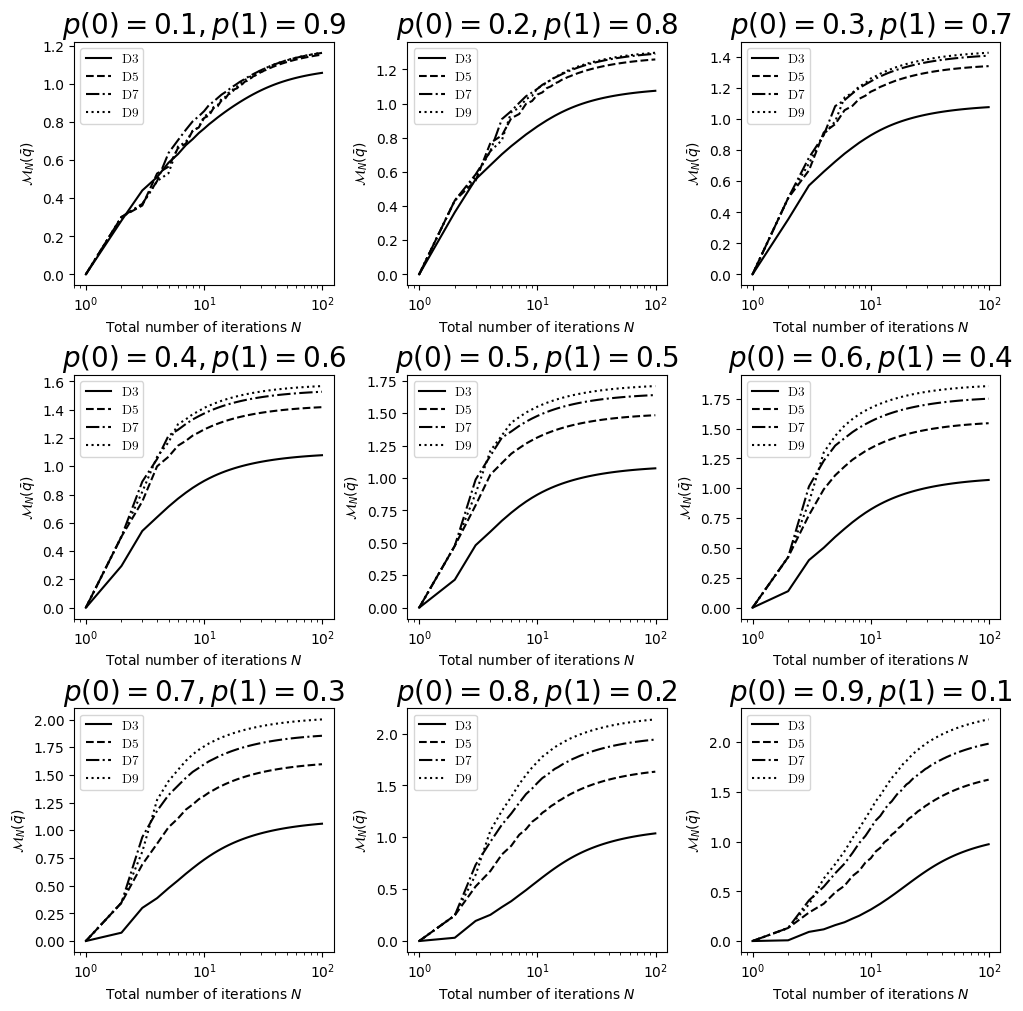

In [ ]:
fig, ax = plt.subplots(3,3,figsize=(10,10), layout='constrained')
ax=ax.flatten()

for i, p in enumerate(np.arange(0.1, 1.0, 0.1)):
  q = 1-p

  Ns = np.arange(1,100)
  # 0    on 0 → 0_a,  on 1 → 1
  # 0_a  on 0 → 0,    on 1 → 1      (cycle wraps, transition still exits)
  # 1    on 0 → 2,    on 1 → 0
  # 2    on 0 → 1,    on 1 → 2_a
  # 2_a  on 0 → 1,    on 1 → 2      (cycle wraps)

  G3 = np.array([
    [p, q, 0],
    [q, 0, p],
    [0, p, q]
  ], dtype=float)

  p0 = [1,0,0]
  G3_mmc = np.array([
      pmmc(p0, G3, N)
      for N in Ns
  ])
  pi = pop(p0, G3, 10_000)
  print(pi)
  print(entropy(p0, pi))
  print(-np.log(1/3 * (1-p) / (1 - p ** 1)))

  G5 = np.array([
  #    0   0_a   1    2   2_a
      [0,   p,   q,   0,   0],   # 0
      [p,   0,   0,   0,   0],   # 0_a
      [q,   q,   0,   p,   p],   # 1
      [0,   0,   p,   0,   q],   # 2
      [0,   0,   0,   q,   0],   # 2_a
  ], dtype=float)
  G5_0 = np.array([
  #  0   0_a   1    2   2_a
    [0,   1,   0,   0,   0],   # 0
    [1,   0,   0,   0,   0],   # 0_a
    [0,   0,   0,   1,   1],   # 1
    [0,   0,   1,   0,   0],   # 2
    [0,   0,   0,   0,   0],   # 2_a
  ])
  G5_1 = np.array([
  #  0   0_a   1    2   2_a
    [0,   0,   1,   0,   0],   # 0
    [0,   0,   0,   0,   0],   # 0_a
    [1,   1,   0,   0,   0],   # 1
    [0,   0,   0,   0,   1],   # 2
    [0,   0,   0,   1,   0],   # 2_a
  ], dtype=float)
  G5 = p * G5_0 + q * G5_1

#   

  p0 = [1,0,0,0,0]
  G5_mmc = np.array([
      pmmc(p0, G5, N)
      for N in Ns
  ])
  pi = pop(p0, G5, 10_000)
  print(pi)
  print(p * pi[0])
  print(entropy(p0, pi))
  print(-np.log(1/3 * (1-p) / (1 - p ** 2)))

  # 0    on 0 → 0_a,  on 1 → 1
  # 0_a  on 0 → 0_b,  on 1 → 1
  # 0_b  on 0 → 0,    on 1 → 1      (cycle wraps)
  # 1    on 0 → 2,    on 1 → 0
  # 2    on 0 → 1,    on 1 → 2_a
  # 2_a  on 0 → 1,    on 1 → 2_b 
  # 2_b  on 0 → 1,    on 1 → 2      (cycle wraps)

  G7 = np.array([
  #    0    0_a  0_b   1    2   2_a  2_b
      [0,   0,   p,   q,   0,   0,   0],   # 0      
      [p,   0,   0,   0,   0,   0,   0],   # 0_a
      [0,   p,   0,   0,   0,   0,   0],   # 0_b
      [q,   q,   q,   0,   p,   p,   p],   # 1
      [0,   0,   0,   p,   0,   0,   q],   # 2
      [0,   0,   0,   0,   q,   0,   0],   # 2_a
      [0,   0,   0,   0,   0,   q,   0],   # 2_b
  ], dtype=float)

  G7_0 = np.array([
  #  0    0_a  0_b   1    2   2_a  2_b
    [0,   0,   1,   0,   0,   0,   0],   # 0      
    [1,   0,   0,   0,   0,   0,   0],   # 0_a
    [0,   1,   0,   0,   0,   0,   0],   # 0_b
    [0,   0,   0,   0,   1,   1,   1],   # 1
    [0,   0,   0,   1,   0,   0,   0],   # 2
    [0,   0,   0,   0,   0,   0,   0],   # 2_a
    [0,   0,   0,   0,   0,   0,   0],   # 2_b
  ], dtype=float)

  G7_1 = np.array([
  #    0    0_a  0_b   1    2   2_a  2_b
    [0,   0,   0,   1,   0,   0,   0],   # 0      
    [0,   0,   0,   0,   0,   0,   0],   # 0_a
    [0,   0,   0,   0,   0,   0,   0],   # 0_b
    [1,   1,   1,   0,   0,   0,   0],   # 1
    [0,   0,   0,   0,   0,   0,   1],   # 2
    [0,   0,   0,   0,   1,   0,   0],   # 2_a
    [0,   0,   0,   0,   0,   1,   0],   # 2_b
  ], dtype=float)

  G7 = p * G7_0 + q * G7_1

  p0=[1,0,0,0,0,0,0]
  G7_mmc = np.array([
      pmmc(p0, G7, N)
      for N in Ns
  ])
  pi = pop(p0, G7, 10_000)
  print(pi)
  print(p * pi[0], p * pi[1])
  print(entropy(p0, pi))
  print(-np.log(1/3 * (1-p) / (1 - p ** 3)))
  print()

  # 0    on 0 → 0_a,  on 1 → 1
  # 0_a  on 0 → 0_b,  on 1 → 1
  # 0_b  on 0 → 0_c,  on 1 → 1
  # 0_c  on 0 → 0,    on 1 → 1      (cycle wraps)
  # 1    on 0 → 2,    on 1 → 0
  # 2    on 0 → 1,    on 1 → 2_a
  # 2_a  on 0 → 1,    on 1 → 2_b
  # 2_b  on 0 → 1,    on 1 → 2_c
  # 2_c  on 0 → 1,    on 1 → 2      (cycle wraps)

  G9 = np.array([
  #    0    0_a  0_b  0_c   1    2   2_a  2_b  2_c
      [0,   0,   0,   p,   q,   0,   0,   0,   0],   # 0
      [p,   0,   0,   0,   0,   0,   0,   0,   0],   # 0_a
      [0,   p,   0,   0,   0,   0,   0,   0,   0],   # 0_b
      [0,   0,   p,   0,   0,   0,   0,   0,   0],   # 0_c
      [q,   q,   q,   q,   0,   p,   p,   p,   p],   # 1
      [0,   0,   0,   0,   p,   0,   0,   0,   q],   # 2
      [0,   0,   0,   0,   0,   q,   0,   0,   0],   # 2_a
      [0,   0,   0,   0,   0,   0,   q,   0,   0],   # 2_b
      [0,   0,   0,   0,   0,   0,   0,   q,   0],   # 2_c
  ], dtype=float)

  p0=[1,0,0,0,0,0,0,0,0]
  G9_mmc = np.array([
      pmmc(p0, G9, N)
      for N in Ns
  ])

  mpl.rcParams.update({
  "font.size": 16,
  "axes.titlesize": 20,
  "axes.labelsize": 16,
  "xtick.labelsize": 9,
  "ytick.labelsize": 9,
  "figure.dpi": 300,
  "savefig.dpi": 300,
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "mathtext.fontset": "dejavusans",
  "text.usetex": True,
  "font.family": "Computer Modern Roman",
  })

  # plt.plot(Ns, G4_mmc, color='red', label='minimal')
  # plt.plot(Ns, G20_mmc, color='blue', label='original')
  ax[i].semilogx(Ns, G3_mmc, color='black', label=r'$\mathrm{D3}$')
  ax[i].semilogx(Ns, G5_mmc, color = 'black' ,linestyle = 'dashed', label=r'$\mathrm{D5}$')
  ax[i].semilogx(Ns, G7_mmc, color='black', linestyle='-.', label=r'$\mathrm{D7}$')
  ax[i].semilogx(Ns, G9_mmc, color='black', linestyle='dotted', label=r'$\mathrm{D9}$')
  ax[i].legend(fontsize='xx-small' ,loc='upper left')
  ax[i].set_title(fr'$p(0)={round(p,1)}, p(1)={round(q, 1)}$')
  ax[i].set_ylabel(r'$\mathcal{M}_N(\bar{q})$')
  ax[i].set_xlabel(r'Total number of iterations $N$')


In [16]:
  mpl.rcParams.update({
  "font.size": 16,
  "axes.titlesize": 20,
  "axes.labelsize": 16,
  "xtick.labelsize": 9,
  "ytick.labelsize": 9,
  "figure.dpi": 300,
  "savefig.dpi": 300,
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "mathtext.fontset": "dejavusans",
  "text.usetex": True,
  "font.family": "Computer Modern Roman",
  })


[0.33 0.33 0.33]
1.0981309230616438
1.0986122886681098
[0.33 0.33 0.18 0.16]
0.03334938271606082
1.0981309230615703
1.1939224684724346
[0.33 0.33 0.12 0.11 0.1 ]
0.03334938271606082 0.03334197530865341
1.0981309230615948
1.2029723039923526



KeyboardInterrupt: 

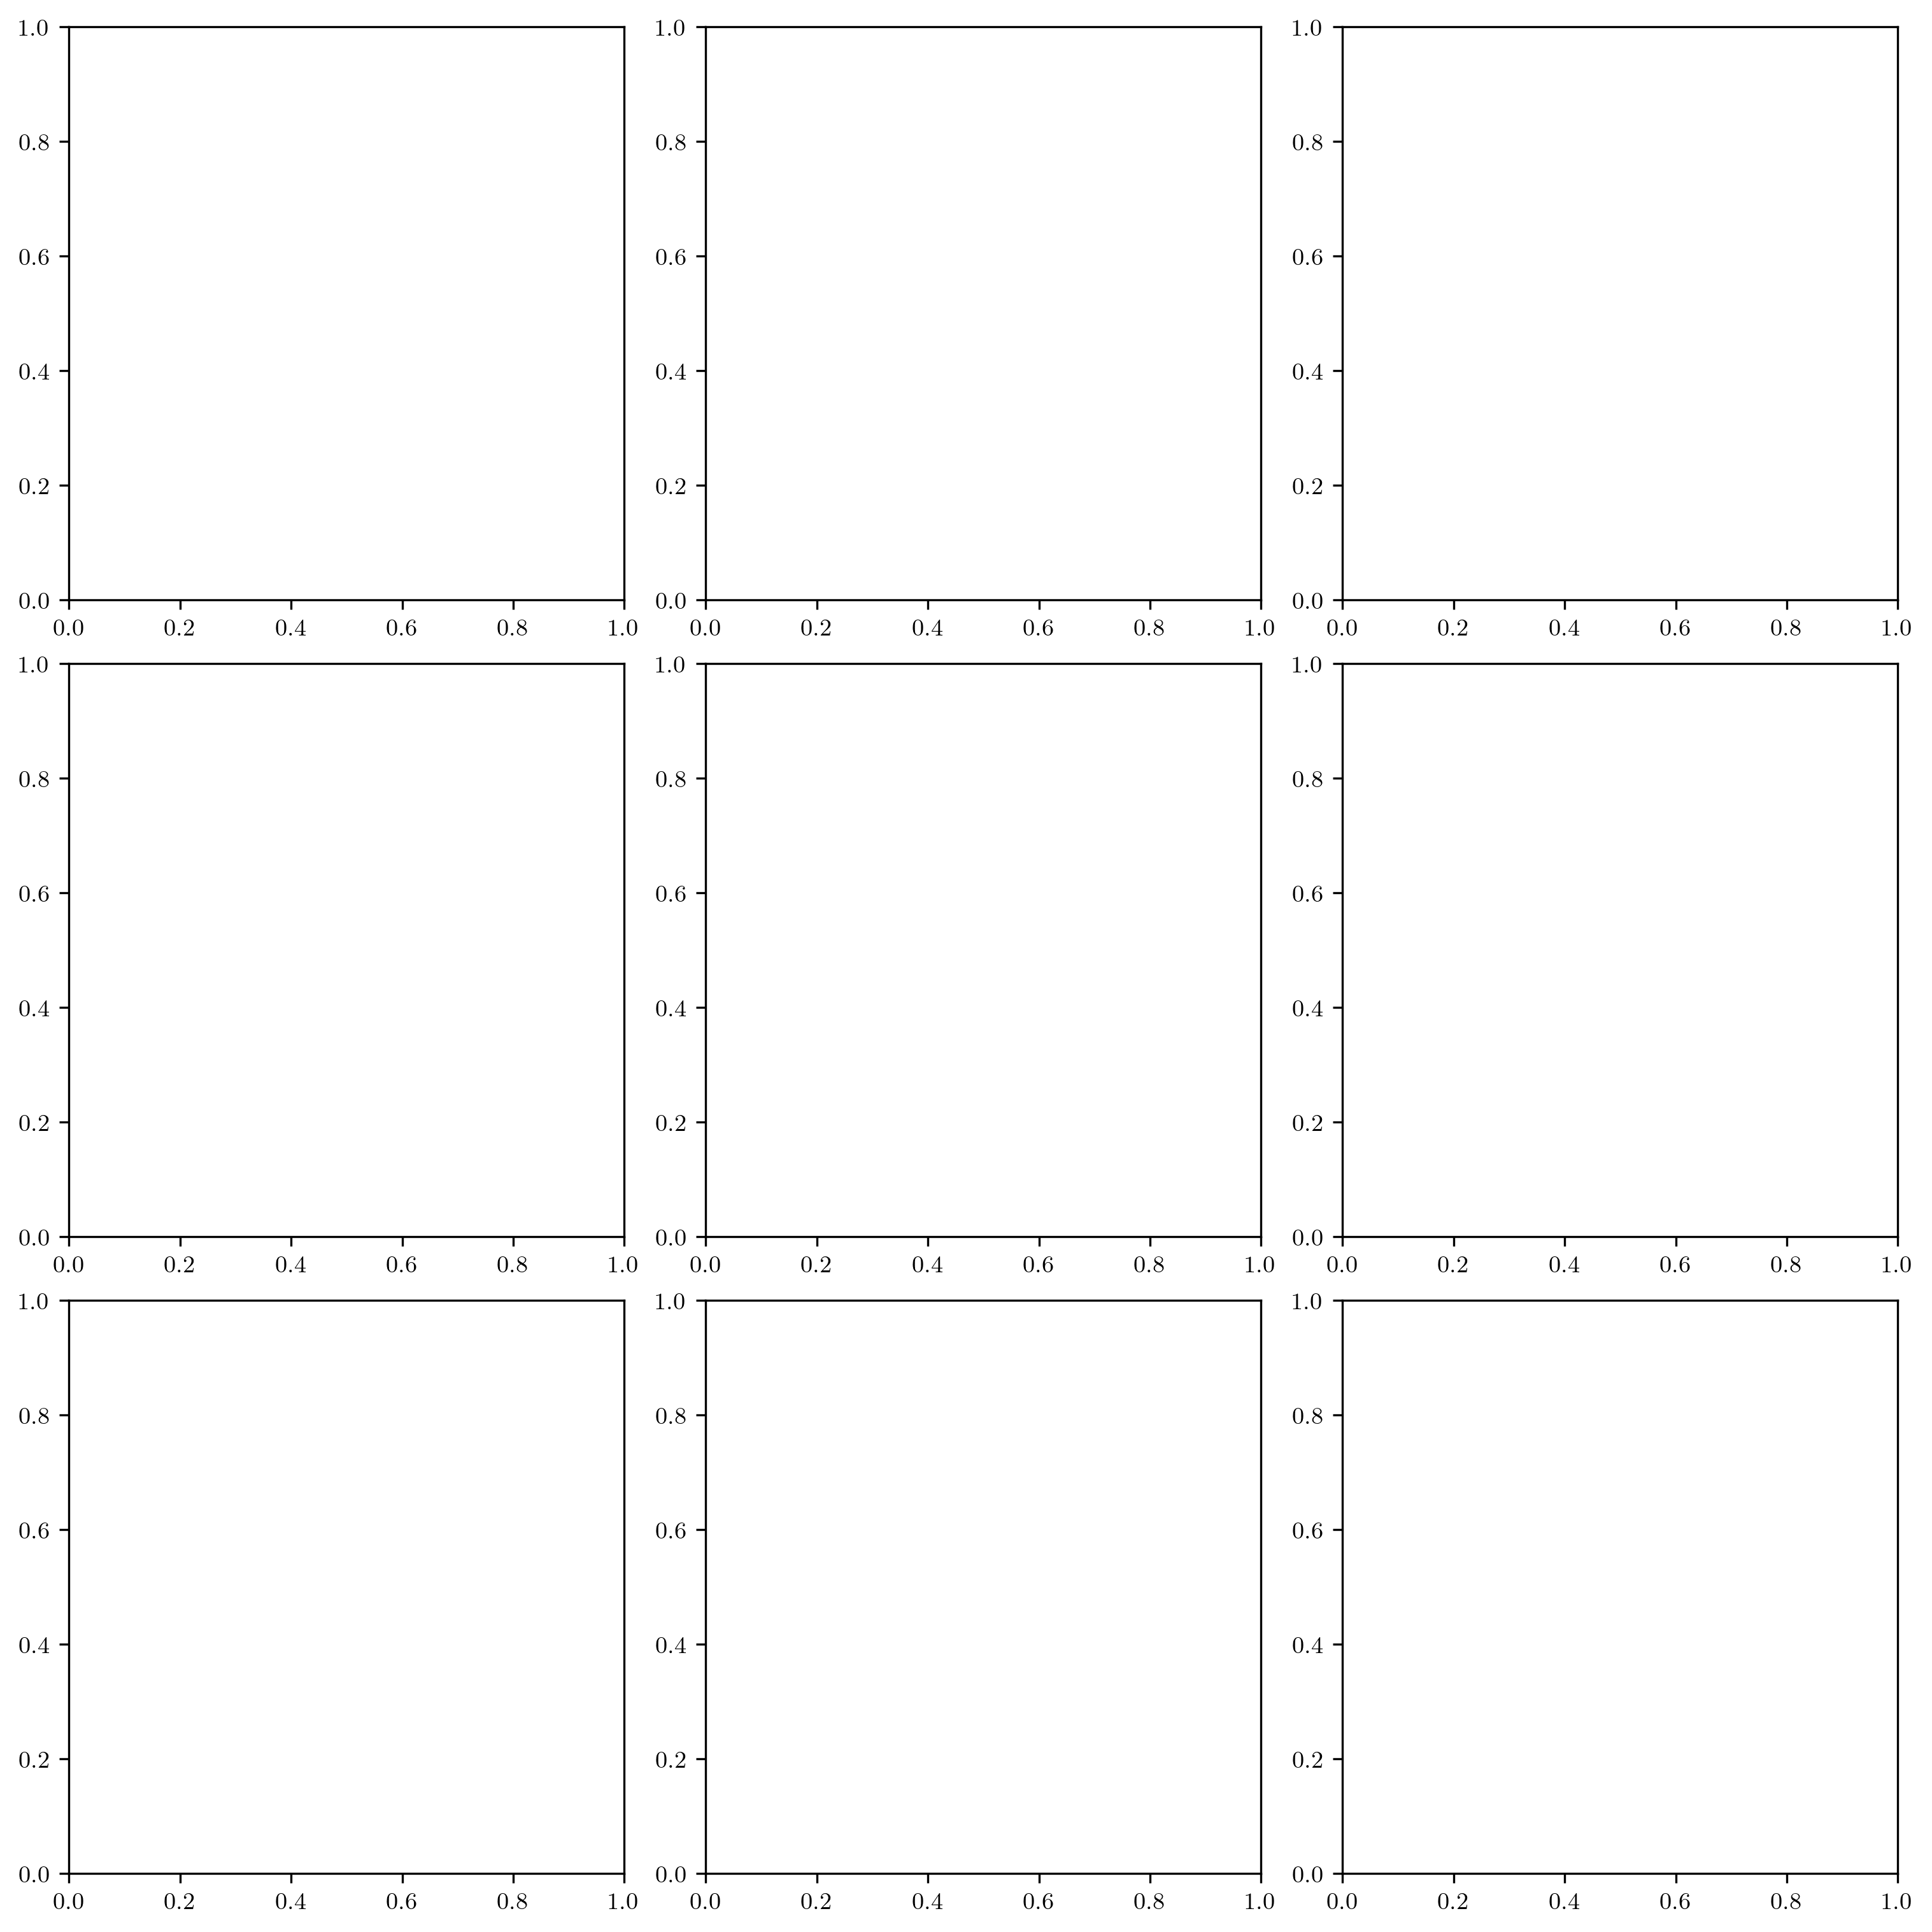

In [23]:
fig, ax = plt.subplots(3,3,figsize=(10,10), layout='constrained')
ax=ax.flatten()
from scipy.linalg import block_diag
def C_L(L_0, L_2):
  return block_diag(np.ones(L_0), np.ones(1), np.ones(L_2))

def make_div3_ops():
  g23 = perms.from_cycles(((2,3),), degree=3)
  g12 = perms.from_cycles(((1,2),), degree=3)
  P0 = perms.perm_hom(g23)
  P1 = perms.perm_hom(g12)
  return P0, P1

Ns = np.arange(1,100)
swap = perms.perm_hom(perms.from_cycles(((1,2),), degree=2))
P0, P1 = make_div3_ops()

for i, p in enumerate(np.arange(0.1, 1.0, 0.1)):
  q = 1 - p


  G3 = p * P0 + q * P1
  L = 1
  p0 = [1,0] + [0] * L
  G3_mmc = np.array([pmmc(p0, G3, N) for N in Ns])
  pi = pop(p0, G3, 10_000)
  print(pi)
  print(entropy(p0, pi))
  print(-np.log(1/3 * (1-p) / (1 - p ** 1)))

  L = 2
  cyc = perms.perm_hom(perms.from_cycles((tuple(range(1,L+1)),), degree=L))
  # 0    on 0 → 0_a,  on 1 → 1
  # 0_a  on 0 → 0,    on 1 → 1      (cycle wraps, transition still exits)
  # 1    on 0 → 2,    on 1 → 0
  # 2    on 0 → 1,    on 1 → 2_a
  # 2_a  on 0 → 1,    on 1 → 2      (cycle wraps)
  G5_0 = block_diag(P0, np.zeros((L-1, L-1)))
  G5_0[1, 2:] = 1
  G5_1 = G7_1 = block_diag(swap, cyc)
  G5 = p * G5_0 + q * G5_1
  p0 = [1,0] + [0] * L
  G5_mmc = np.array([pmmc(p0, G5, N) for N in Ns])
  pi = pop(p0, G5, 10_000)
  print(pi)
  print(p * pi[0])
  print(entropy(p0, pi))
  print(-np.log(1/3 * (1-p) / (1 - p ** 2)))

  L = 3
  cyc = perms.perm_hom(perms.from_cycles((tuple(range(1,L+1)),), degree=L))
  # 0    on 0 → 0_a,  on 1 → 1
  # 0_a  on 0 → 0_b,  on 1 → 1
  # 0_b  on 0 → 0,    on 1 → 1      (cycle wraps)
  # 1    on 0 → 2,    on 1 → 0
  # 2    on 0 → 1,    on 1 → 2_a
  # 2_a  on 0 → 1,    on 1 → 2_b 
  # 2_b  on 0 → 1,    on 1 → 2      (cycle wraps)
  G7_0 = block_diag(P0, np.zeros((L-1, L-1)))
  G7_0[1, 2:] = 1
  G7_1 = block_diag(swap, cyc)
  G7 = p * G7_0 + q * G7_1
  p0 = [1,0] + [0] * L
  G7_mmc = np.array([pmmc(p0, G7, N) for N in Ns])
  pi = pop(p0, G7, 10_000)
  print(pi)
  print(p * pi[0], p * pi[1])
  print(entropy(p0, pi))
  print(-np.log(1/3 * (1-p) / (1 - p ** 3)))
  print()

  # 0    on 0 → 0_a,  on 1 → 1
  # 0_a  on 0 → 0_b,  on 1 → 1
  # 0_b  on 0 → 0_c,  on 1 → 1
  # 0_c  on 0 → 0,    on 1 → 1      (cycle wraps)
  # 1    on 0 → 2,    on 1 → 0
  # 2    on 0 → 1,    on 1 → 2_a
  # 2_a  on 0 → 1,    on 1 → 2_b
  # 2_b  on 0 → 1,    on 1 → 2_c
  # 2_c  on 0 → 1,    on 1 → 2      (cycle wraps)

  L = 4
  cyc = perms.perm_hom(perms.from_cycles((tuple(range(1,L+1)),), degree=L))
  G9_0 = block_diag(P0, np.zeros((L-1, L-1)))
  G9_0[1, 2:] = 1
  G9_1 = block_diag(swap, cyc)
  G9 = p * G9_0 + q * G9_1
  p0 = [1, 0] + [0] * L
  G9_mmc = np.array([pmmc(p0, G9, N) for N in Ns])

  L = 2000
  cyc = perms.perm_hom(perms.from_cycles((tuple(range(1,L+1)),), degree=L))
  G8_1 = block_diag(swap, cyc)
  G8_0 = block_diag(P0, np.zeros((L-1, L-1)))
  G8_0[1, 2:] = 1
  G8 = p * G8_0 + q * G8_1
  p0 = [1, 0] + [0] * L
  G8_mmc = np.array([pmmc(p0, G8, N) for N in Ns])

  # plt.plot(Ns, G4_mmc, color='red', label='minimal')
  # plt.plot(Ns, G20_mmc, color='blue', label='original')
  ax[i].semilogx(Ns, G3_mmc, color='black', label=r'$\mathrm{D3}$')
  ax[i].semilogx(Ns, G5_mmc, color = 'black' ,linestyle = 'dashed', label=r'$\mathrm{D5}$')
  ax[i].semilogx(Ns, G7_mmc, color='black', linestyle='-.', label=r'$\mathrm{D7}$')
  ax[i].semilogx(Ns, G9_mmc, color='black', linestyle='dotted', label=r'$\mathrm{D9}$')
  ax[i].semilogx(Ns, G8_mmc, color='red', linestyle='dotted', label=r'$\mathrm{D8}$')
  ax[i].legend(fontsize='xx-small' ,loc='upper left')
  ax[i].set_title(fr'$p(0)={round(p,1)}, p(1)={round(q, 1)}$')
  ax[i].set_ylabel(r'$\mathcal{M}_N(\bar{q})$')
  ax[i].set_xlabel(r'Total number of iterations $N$')


[0.33493827 0.33419753 0.3308642 ]
[0.33493827 0.         0.33419753 0.3308642  0.        ]
[0.33493827 0.         0.         0.33419753 0.3308642  0.
 0.        ]

[0.33444444 0.33361111 0.33194444]
[0.33444444 0.         0.33361111 0.33194444 0.        ]
[0.33444444 0.         0.         0.33361111 0.33194444 0.
 0.        ]

[0.33433862 0.33338624 0.33227513]
[0.33433862 0.         0.33338624 0.33227513 0.        ]
[0.33433862 0.         0.         0.33338624 0.33227513 0.
 0.        ]

[0.33435185 0.33324074 0.33240741]
[0.33435185 0.         0.33324074 0.33240741 0.        ]
[0.33435185 0.         0.         0.33324074 0.33240741 0.
 0.        ]

[0.33444444 0.33311111 0.33244444]
[0.33444444 0.         0.33311111 0.33244444 0.        ]
[0.33444444 0.         0.         0.33311111 0.33244444 0.
 0.        ]

[0.33462963 0.33296296 0.33240741]
[0.33462963 0.         0.33296296 0.33240741 0.        ]
[0.33462963 0.         0.         0.33296296 0.33240741 0.
 0.        ]

[0.3349735

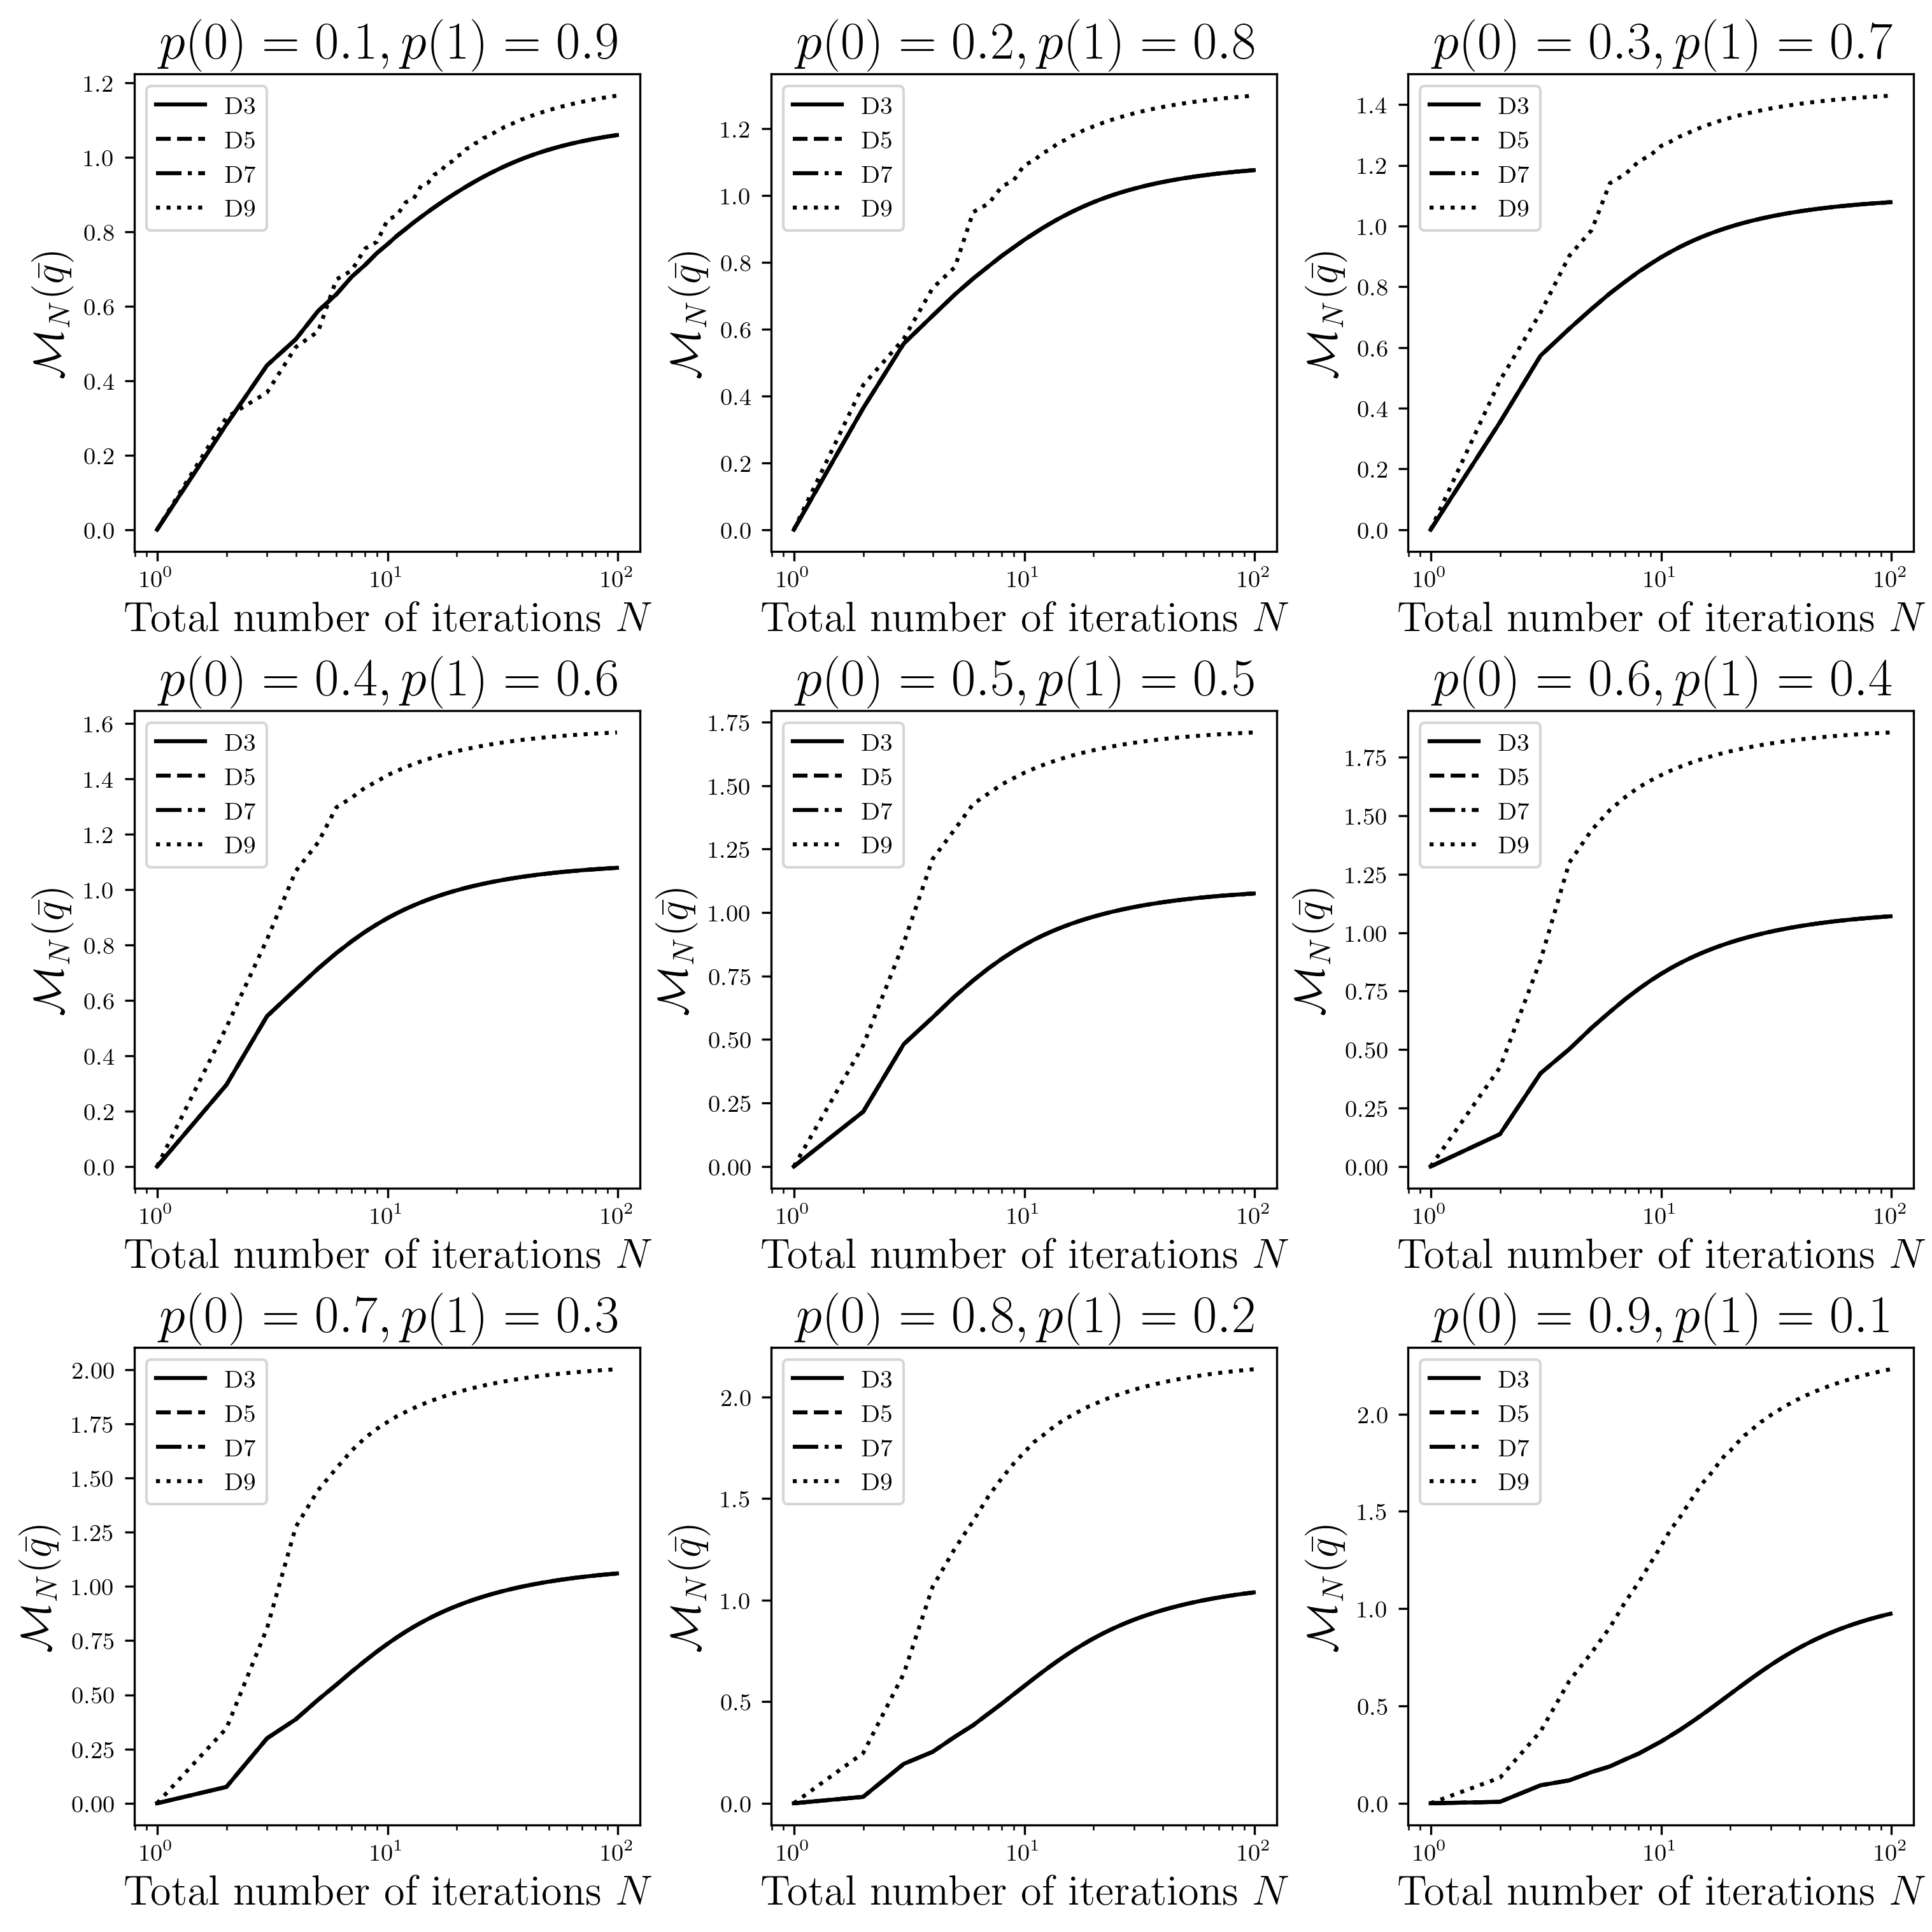

In [6]:
fig, ax = plt.subplots(3,3,figsize=(10,10), layout='constrained')
ax=ax.flatten()

for i, p in enumerate(np.arange(0.1, 1.0, 0.1)):
  q = 1-p

  Ns = np.arange(1,100)
  # 0    on 0 → 0_a,  on 1 → 1
  # 0_a  on 0 → 0,    on 1 → 1      (cycle wraps, transition still exits)
  # 1    on 0 → 2,    on 1 → 0
  # 2    on 0 → 1,    on 1 → 2_a
  # 2_a  on 0 → 1,    on 1 → 2      (cycle wraps)

  G3 = np.array([
      [p, q, 0],
      [q, 0, p],
      [0, p, q]
  ], dtype=float)

  p0 = [1,0,0]
  G3_mmc = np.array([
      pmmc(p0, G3, N)
      for N in Ns
  ])

  print(pop(p0, G3, 1000))


  G5_0 = np.array([
  #  0   0_a   1    2   2_a
    [1,   0,   0,   0,   0],   # 0
    [0,   1,   0,   0,   0],   # 0_a
    [0,   0,   0,   1,   1],   # 1
    [0,   0,   1,   0,   0],   # 2
    [0,   0,   0,   0,   0],   # 2_a
  ])
  G5_1 = np.array([
  #  0   0_a   1    2   2_a
    [0,   0,   1,   0,   0],   # 0
    [0,   0,   0,   0,   0],   # 0_a
    [1,   1,   0,   0,   0],   # 1
    [0,   0,   0,   1,   0],   # 2
    [0,   0,   0,   0,   1],   # 2_a
  ], dtype=float)
  G5 = p * G5_0 + q * G5_1

#   

  p0 = [1,0,0,0,0]
  G5_mmc = np.array([
      pmmc(p0, G5, N)
      for N in Ns
  ])

  print(pop(p0, G5, 1000))

  # 0    on 0 → 0_a,  on 1 → 1
  # 0_a  on 0 → 0_b,  on 1 → 1
  # 0_b  on 0 → 0,    on 1 → 1      (cycle wraps)
  # 1    on 0 → 2,    on 1 → 0
  # 2    on 0 → 1,    on 1 → 2_a
  # 2_a  on 0 → 1,    on 1 → 2_b 
  # 2_b  on 0 → 1,    on 1 → 2      (cycle wraps)


  G7_0 = np.array([
  #  0    0_a  0_b   1    2   2_a  2_b
    [1,   0,   0,   0,   0,   0,   0],   # 0      
    [0,   1,   0,   0,   0,   0,   0],   # 0_a
    [0,   0,   1,   0,   0,   0,   0],   # 0_b
    [0,   0,   0,   0,   1,   1,   1],   # 1
    [0,   0,   0,   1,   0,   0,   0],   # 2
    [0,   0,   0,   0,   0,   0,   0],   # 2_a
    [0,   0,   0,   0,   0,   0,   0],   # 2_b
  ], dtype=float)

  G7_1 = np.array([
  #    0    0_a  0_b   1    2   2_a  2_b
    [0,   0,   0,   1,   0,   0,   0],   # 0      
    [0,   0,   0,   0,   0,   0,   0],   # 0_a
    [0,   0,   0,   0,   0,   0,   0],   # 0_b
    [1,   1,   1,   0,   0,   0,   0],   # 1
    [0,   0,   0,   0,   1,   0,   0],   # 2
    [0,   0,   0,   0,   0,   1,   0],   # 2_a
    [0,   0,   0,   0,   0,   0,   1],   # 2_b
  ], dtype=float)

  G7 = p * G7_0 + q * G7_1

  p0=[1,0,0,0,0,0,0]
  G7_mmc = np.array([
      pmmc(p0, G7, N)
      for N in Ns
  ])

  print(pop(p0, G7, 1000))
  print()

  # 0    on 0 → 0_a,  on 1 → 1
  # 0_a  on 0 → 0_b,  on 1 → 1
  # 0_b  on 0 → 0_c,  on 1 → 1
  # 0_c  on 0 → 0,    on 1 → 1      (cycle wraps)
  # 1    on 0 → 2,    on 1 → 0
  # 2    on 0 → 1,    on 1 → 2_a
  # 2_a  on 0 → 1,    on 1 → 2_b
  # 2_b  on 0 → 1,    on 1 → 2_c
  # 2_c  on 0 → 1,    on 1 → 2      (cycle wraps)

  G9 = np.array([
  #    0    0_a  0_b  0_c   1    2   2_a  2_b  2_c
      [0,   0,   0,   p,   q,   0,   0,   0,   0],   # 0
      [p,   0,   0,   0,   0,   0,   0,   0,   0],   # 0_a
      [0,   p,   0,   0,   0,   0,   0,   0,   0],   # 0_b
      [0,   0,   p,   0,   0,   0,   0,   0,   0],   # 0_c
      [q,   q,   q,   q,   0,   p,   p,   p,   p],   # 1
      [0,   0,   0,   0,   p,   0,   0,   0,   q],   # 2
      [0,   0,   0,   0,   0,   q,   0,   0,   0],   # 2_a
      [0,   0,   0,   0,   0,   0,   q,   0,   0],   # 2_b
      [0,   0,   0,   0,   0,   0,   0,   q,   0],   # 2_c
  ], dtype=float)

  p0=[1,0,0,0,0,0,0,0,0]
  G9_mmc = np.array([
      pmmc(p0, G9, N)
      for N in Ns
  ])

  mpl.rcParams.update({
  "font.size": 16,
  "axes.titlesize": 20,
  "axes.labelsize": 16,
  "xtick.labelsize": 9,
  "ytick.labelsize": 9,
  "figure.dpi": 300,
  "savefig.dpi": 300,
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "mathtext.fontset": "dejavusans",
  "text.usetex": True,
  "font.family": "Computer Modern Roman",
  })

  # plt.plot(Ns, G4_mmc, color='red', label='minimal')
  # plt.plot(Ns, G20_mmc, color='blue', label='original')
  ax[i].semilogx(Ns, G3_mmc, color='black', label=r'$\mathrm{D3}$')
  ax[i].semilogx(Ns, G5_mmc, color = 'black' ,linestyle = 'dashed', label=r'$\mathrm{D5}$')
  ax[i].semilogx(Ns, G7_mmc, color='black', linestyle='-.', label=r'$\mathrm{D7}$')
  ax[i].semilogx(Ns, G9_mmc, color='black', linestyle='dotted', label=r'$\mathrm{D9}$')
  ax[i].legend(fontsize='xx-small' ,loc='upper left')
  ax[i].set_title(fr'$p(0)={round(p,1)}, p(1)={round(q, 1)}$')
  ax[i].set_ylabel(r'$\mathcal{M}_N(\bar{q})$')
  ax[i].set_xlabel(r'Total number of iterations $N$')


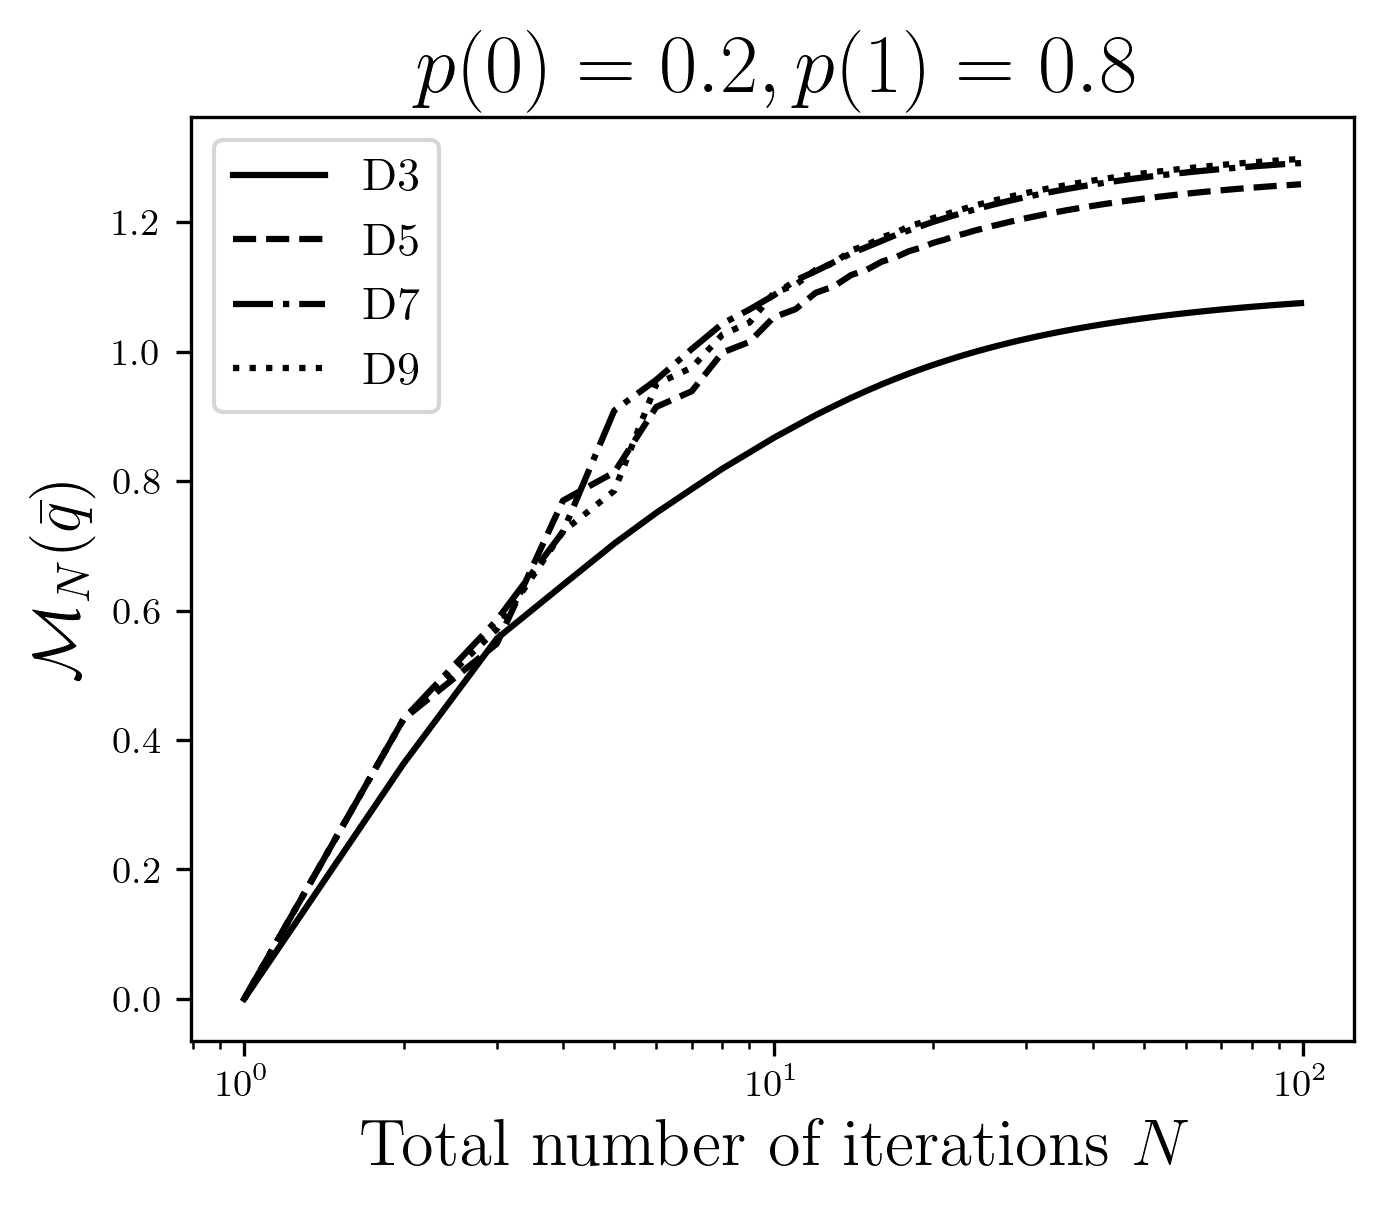

In [157]:
mpl.rcParams.update({
  "font.size": 16,
  "axes.titlesize": 20,
  "axes.labelsize": 16,
  "xtick.labelsize": 9,
  "ytick.labelsize": 9,
  "figure.dpi": 300,
  "savefig.dpi": 300,
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "mathtext.fontset": "dejavusans",
  "text.usetex": True,
  "font.family": "Computer Modern Roman",
})

fig, ax = plt.subplots(figsize=(5,4))

# plt.plot(Ns, G4_mmc, color='red', label='minimal')
# plt.plot(Ns, G20_mmc, color='blue', label='original')
ax.semilogx(Ns, G3_mmc, color='black', label=r'$\mathrm{D3}$')
ax.semilogx(Ns, G5_mmc, color = 'black' ,linestyle = 'dashed', label=r'$\mathrm{D5}$')
ax.semilogx(Ns, G7_mmc, color='black', linestyle='-.', label=r'$\mathrm{D7}$')
ax.semilogx(Ns, G9_mmc, color='black', linestyle='dotted', label=r'$\mathrm{D9}$')
ax.legend(fontsize='x-small' ,loc='upper left')
ax.set_title(fr'$p(0)={p}, p(1)={round(q, 1)}$')
ax.set_ylabel(r'$\mathcal{M}_N(\bar{q})$')
ax.set_xlabel(r'Total number of iterations $N$')

plt.savefig('/Users/benjmainansbacher/Documents/POP projectg/DFAplot.pdf')

Text(0.5, 0, 'Total number of iterations $N$')

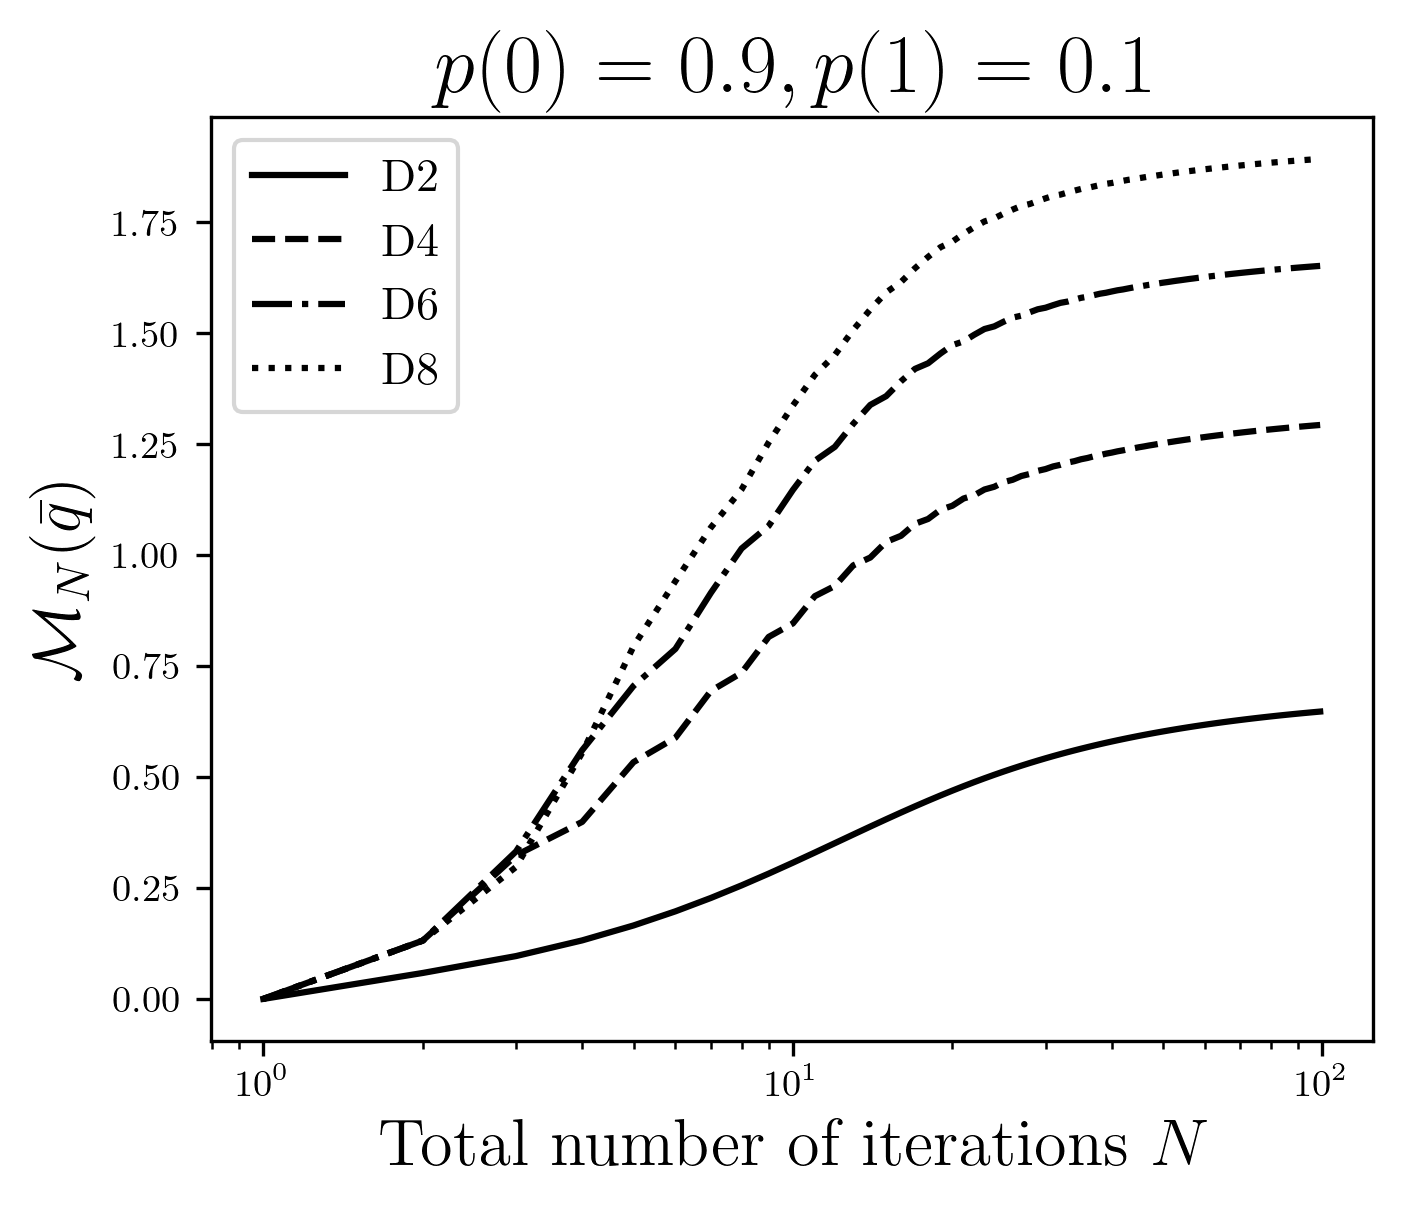

In [9]:
Ns=np.arange(1,100)

p = 0.9
q=1-p

# G2 — minimal
# State 0: even parity (accept)
# State 1: odd parity
# Transitions: new_r = (r + b) mod 2

G2 = np.array([
#    0    1
    [p,   q],   # 0
    [q,   p],   # 1
], dtype=float)

# G4 — 1 cycle state each
# States: 0, 0_a, 1, 1_a

p0=[1,0]
G2mmc = [pmmc(p0, G2, N) for N in Ns]

G4 = np.array([
#    0    0_a   1   1_a
    [0,   p,   q,   q],   # 0
    [p,   0,   0,   0],   # 0_a
    [q,   q,   0,   p],   # 1
    [0,   0,   p,   0],   # 1_a
], dtype=float)

p0=[1,0,0,0]
G4mmc = [pmmc(p0, G4, N) for N in Ns]

# G6 — 2 cycle states each
# States: 0, 0_a, 0_b, 1, 1_a, 1_b

G6 = np.array([
#    0    0_a  0_b   1   1_a  1_b
    [0,   0,   p,   q,   q,   q],   # 0
    [p,   0,   0,   0,   0,   0],   # 0_a
    [0,   p,   0,   0,   0,   0],   # 0_b
    [q,   q,   q,   0,   0,   p],   # 1
    [0,   0,   0,   p,   0,   0],   # 1_a
    [0,   0,   0,   0,   p,   0],   # 1_b
], dtype=float)

p0=[1,0,0,0,0,0]
G6mmc = [pmmc(p0, G6, N) for N in Ns]

# G8 — 3 cycle states each
# States: 0, 0_a, 0_b, 0_c, 1, 1_a, 1_b, 1_c

G8 = np.array([
#    0    0_a  0_b  0_c   1   1_a  1_b  1_c
    [0,   0,   0,   p,   q,   q,   q,   q],   # 0
    [p,   0,   0,   0,   0,   0,   0,   0],   # 0_a
    [0,   p,   0,   0,   0,   0,   0,   0],   # 0_b
    [0,   0,   p,   0,   0,   0,   0,   0],   # 0_c
    [q,   q,   q,   q,   0,   0,   0,   p],   # 1
    [0,   0,   0,   0,   p,   0,   0,   0],   # 1_a
    [0,   0,   0,   0,   0,   p,   0,   0],   # 1_b
    [0,   0,   0,   0,   0,   0,   p,   0],   # 1_c
], dtype=float)

p0=[1,0,0,0,0,0,0,0]
G8mmc = [pmmc(p0, G8, N) for N in Ns]

mpl.rcParams.update({
  "font.size": 16,
  "axes.titlesize": 20,
  "axes.labelsize": 16,
  "xtick.labelsize": 9,
  "ytick.labelsize": 9,
  "figure.dpi": 300,
  "savefig.dpi": 300,
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "mathtext.fontset": "dejavusans",
  "text.usetex": True,
  "font.family": "Computer Modern Roman",
})

fig, ax = plt.subplots(figsize=(5,4))

# plt.plot(Ns, G4_mmc, color='red', label='minimal')
# plt.plot(Ns, G20_mmc, color='blue', label='original')
ax.semilogx(Ns, G2mmc, color='black', label=r'$\mathrm{D2}$')
ax.semilogx(Ns, G4mmc, color = 'black' ,linestyle = 'dashed', label=r'$\mathrm{D4}$')
ax.semilogx(Ns, G6mmc, color='black', linestyle='-.', label=r'$\mathrm{D6}$')
ax.semilogx(Ns, G8mmc, color='black', linestyle='dotted', label=r'$\mathrm{D8}$')
ax.legend(fontsize='x-small' ,loc='upper left')
ax.set_title(fr'$p(0)={p}, p(1)={round(q, 1)}$')
ax.set_ylabel(r'$\mathcal{M}_N(\bar{q})$')
ax.set_xlabel(r'Total number of iterations $N$')

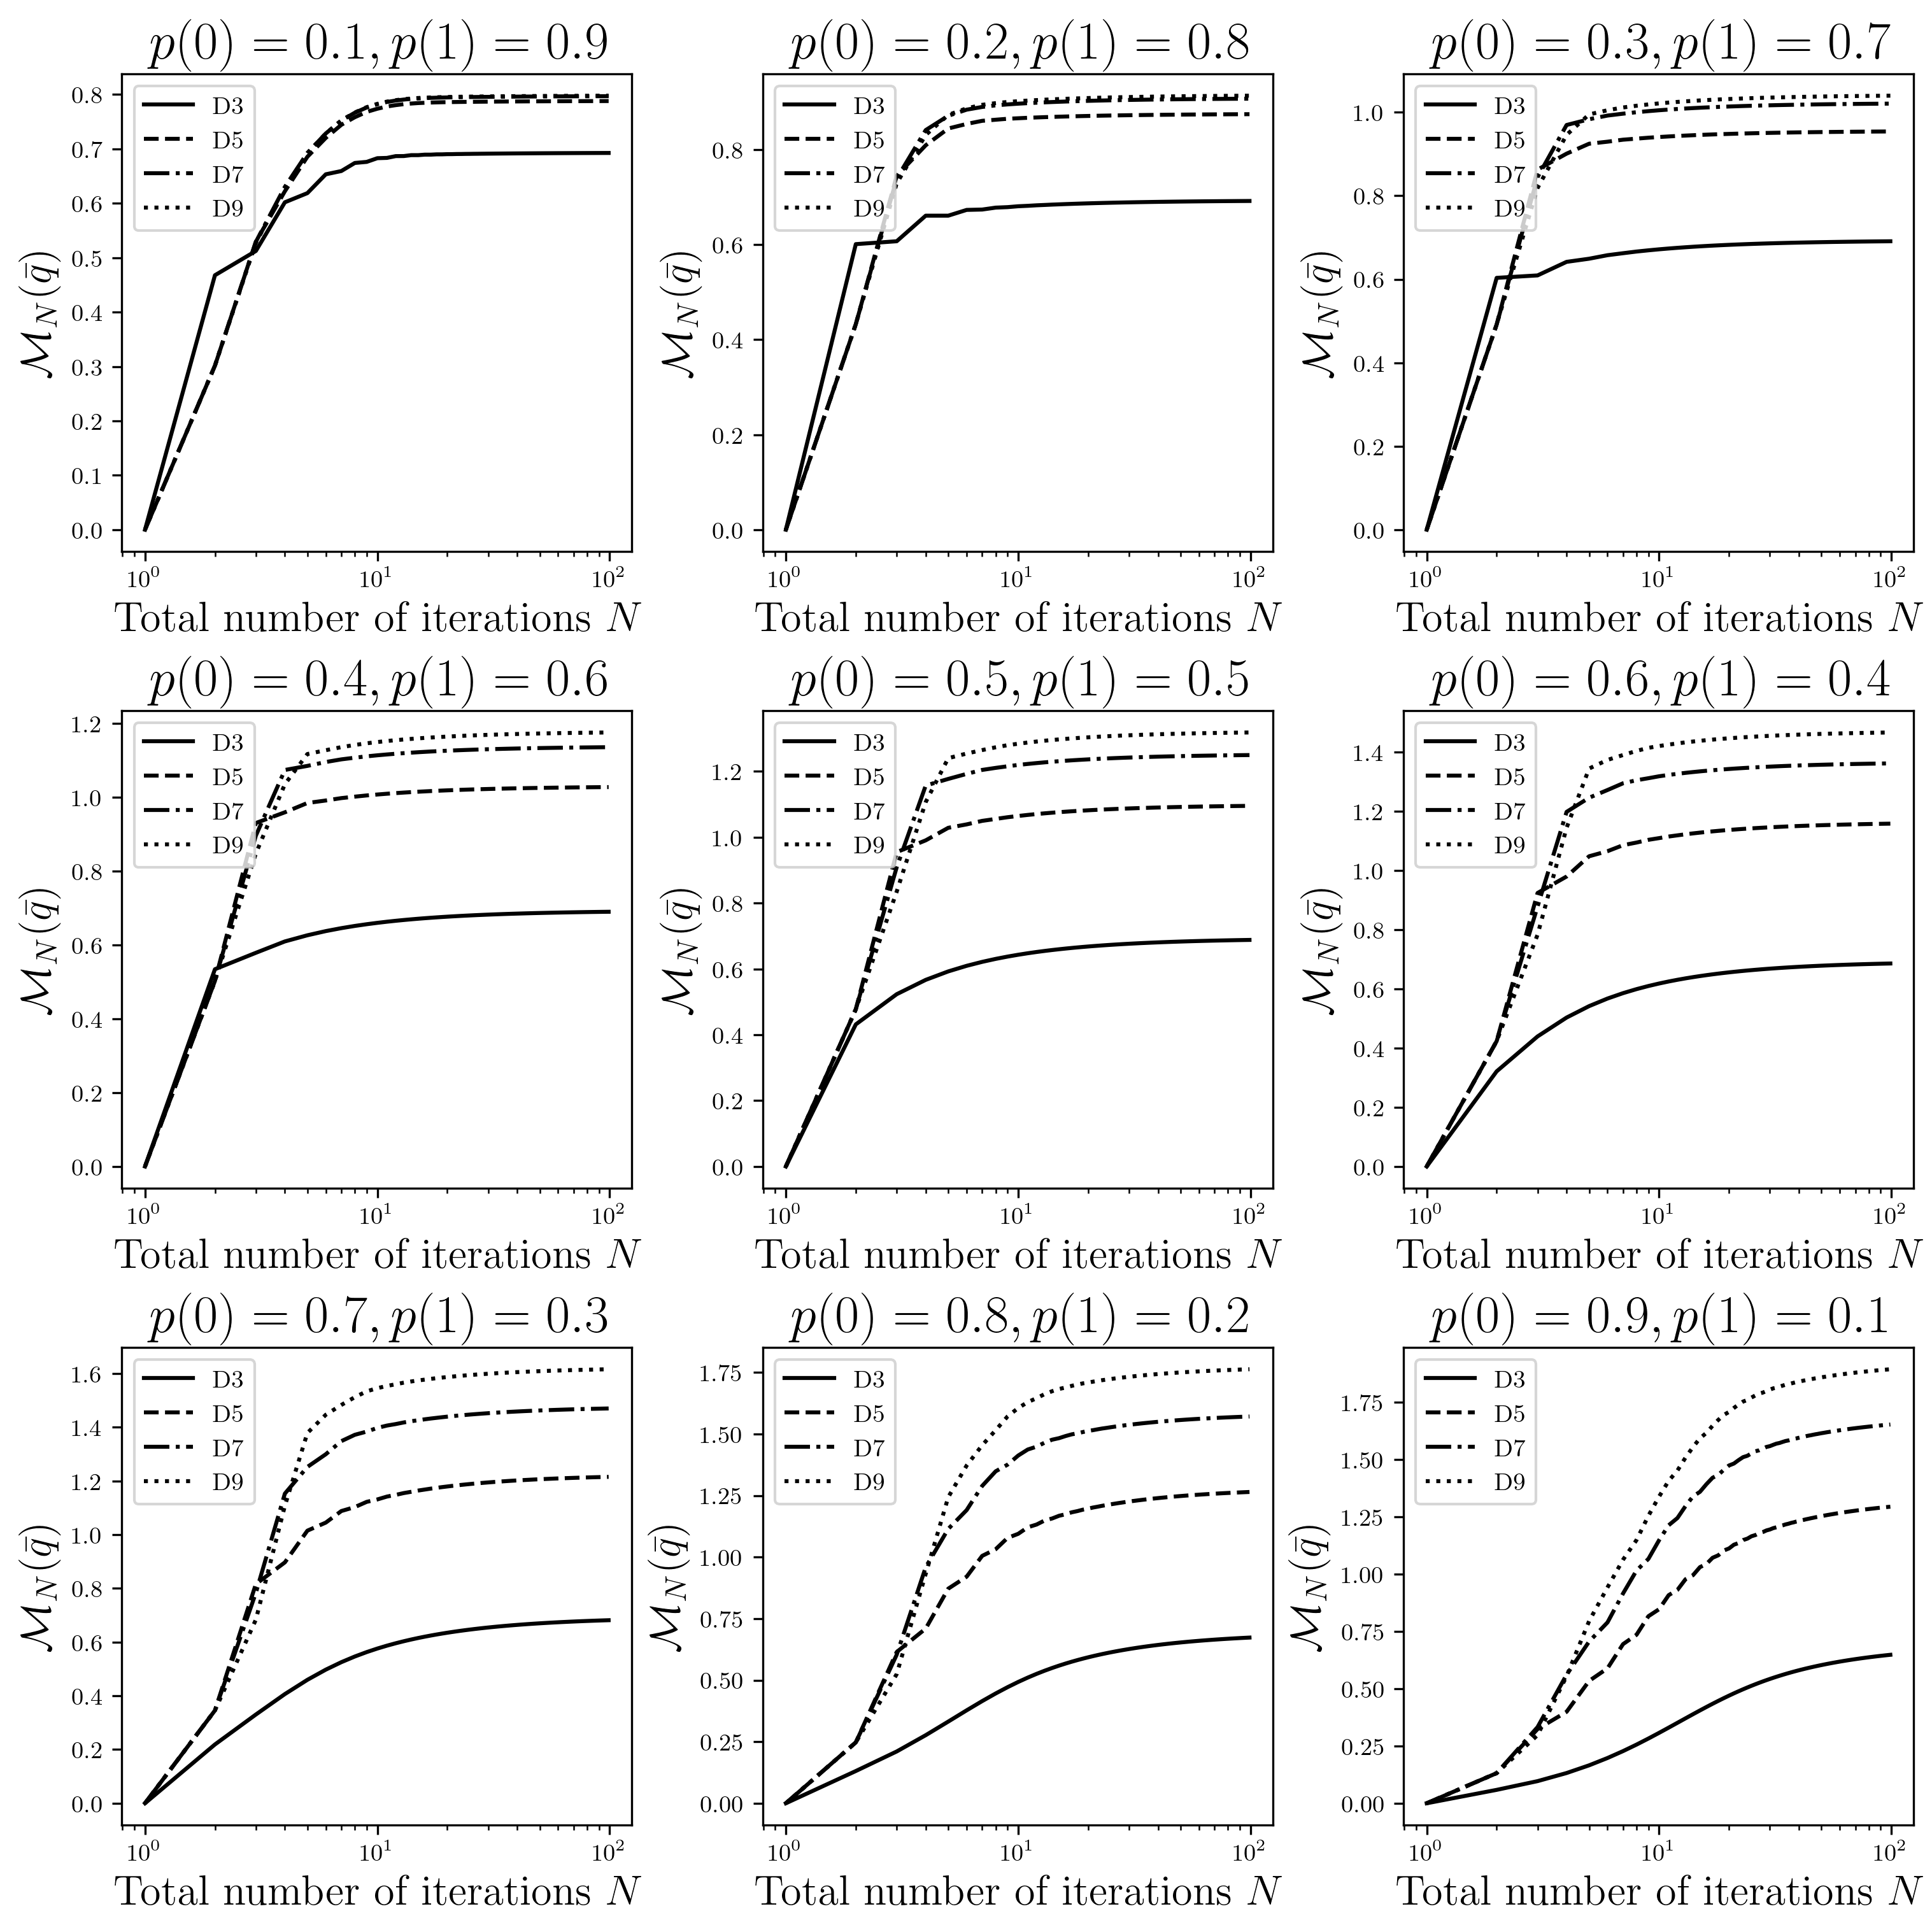

In [11]:
fig, ax = plt.subplots(3,3,figsize=(10,10), layout='constrained')
ax=ax.flatten()

for i, p in enumerate(np.arange(0.1, 1.0, 0.1)):
    q = 1-p

    G2 = np.array([
    #    0    1
        [p,   q],   # 0
        [q,   p],   # 1
    ], dtype=float)

    # G4 — 1 cycle state each
    # States: 0, 0_a, 1, 1_a

    p0=[1,0]
    G2mmc = [pmmc(p0, G2, N) for N in Ns]

    G4 = np.array([
    #    0    0_a   1   1_a
        [0,   p,   q,   q],   # 0
        [p,   0,   0,   0],   # 0_a
        [q,   q,   0,   p],   # 1
        [0,   0,   p,   0],   # 1_a
    ], dtype=float)

    p0=[1,0,0,0]
    G4mmc = [pmmc(p0, G4, N) for N in Ns]

    # G6 — 2 cycle states each
    # States: 0, 0_a, 0_b, 1, 1_a, 1_b

    G6 = np.array([
    #    0    0_a  0_b   1   1_a  1_b
        [0,   0,   p,   q,   q,   q],   # 0
        [p,   0,   0,   0,   0,   0],   # 0_a
        [0,   p,   0,   0,   0,   0],   # 0_b
        [q,   q,   q,   0,   0,   p],   # 1
        [0,   0,   0,   p,   0,   0],   # 1_a
        [0,   0,   0,   0,   p,   0],   # 1_b
    ], dtype=float)

    p0=[1,0,0,0,0,0]
    G6mmc = [pmmc(p0, G6, N) for N in Ns]

    # G8 — 3 cycle states each
    # States: 0, 0_a, 0_b, 0_c, 1, 1_a, 1_b, 1_c

    G8 = np.array([
    #    0    0_a  0_b  0_c   1   1_a  1_b  1_c
        [0,   0,   0,   p,   q,   q,   q,   q],   # 0
        [p,   0,   0,   0,   0,   0,   0,   0],   # 0_a
        [0,   p,   0,   0,   0,   0,   0,   0],   # 0_b
        [0,   0,   p,   0,   0,   0,   0,   0],   # 0_c
        [q,   q,   q,   q,   0,   0,   0,   p],   # 1
        [0,   0,   0,   0,   p,   0,   0,   0],   # 1_a
        [0,   0,   0,   0,   0,   p,   0,   0],   # 1_b
        [0,   0,   0,   0,   0,   0,   p,   0],   # 1_c
    ], dtype=float)

    p0=[1,0,0,0,0,0,0,0]
    G8mmc = [pmmc(p0, G8, N) for N in Ns]

    mpl.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "mathtext.fontset": "dejavusans",
    "text.usetex": True,
    "font.family": "Computer Modern Roman",
    })

    # plt.plot(Ns, G4_mmc, color='red', label='minimal')
    # plt.plot(Ns, G20_mmc, color='blue', label='original')
    ax[i].semilogx(Ns, G2mmc, color='black', label=r'$\mathrm{D3}$')
    ax[i].semilogx(Ns, G4mmc, color = 'black' ,linestyle = 'dashed', label=r'$\mathrm{D5}$')
    ax[i].semilogx(Ns, G6mmc, color='black', linestyle='-.', label=r'$\mathrm{D7}$')
    ax[i].semilogx(Ns, G8mmc, color='black', linestyle='dotted', label=r'$\mathrm{D9}$')
    ax[i].legend(fontsize='xx-small' ,loc='upper left')
    ax[i].set_title(fr'$p(0)={round(p,1)}, p(1)={round(q, 1)}$')
    ax[i].set_ylabel(r'$\mathcal{M}_N(\bar{q})$')
    ax[i].set_xlabel(r'Total number of iterations $N$')